In [1]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn scikit-learn openpyxl
!pip install casanovo
!pip install pyteomics lxml

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import casanovo
import os

In [5]:
ecoli_path = '/content/drive/MyDrive/peptide_project/Data/Ecoli/'
wastewater_path = '/content/drive/MyDrive/peptide_project/Data/Wastewater/'

In [7]:
print("\nSummary of Ecoli files:")
for f in os.listdir(ecoli_path):
    size = os.path.getsize(ecoli_path + f) / (1024*1024)
    print("- {} ({:.1f} MB)".format(f, size))

print("\nSummary of Wastewater files:")
for f in os.listdir(wastewater_path):
    size = os.path.getsize(wastewater_path + f) / (1024*1024)
    print("- {} ({:.1f} MB)".format(f, size))


Summary of Ecoli files:
- Ecoli_EV_1.mzML (1005.7 MB)
- Ecoli_EV_2.mzML (984.9 MB)
- Database search output_Ecoli_EV_2.xlsx (1.6 MB)
- Database search output_Ecoli_EV_1.xlsx (1.4 MB)

Summary of Wastewater files:
- wastewater_Sample1_1.mzML (525.3 MB)
- wastewater_Sample1_2.mzML (515.0 MB)
- wastewater_Sample2_1.mzML (547.2 MB)
- wastewater_Sample2_2.mzML (539.2 MB)


In [8]:
df1 = pd.read_excel(ecoli_path + 'Database search output_Ecoli_EV_1.xlsx')
df2 = pd.read_excel(ecoli_path + 'Database search output_Ecoli_EV_2.xlsx')

ecoli_df = pd.concat([df1, df2], ignore_index=True)

print(f"Total peptides in the dataset: {len(ecoli_df)}")
print(f"\nColumn names present here:")
print(ecoli_df.columns.tolist())
print(f"\nFirst 5 rows present:")
ecoli_df.head(5)

Total peptides in the dataset: 3162

Column names present here:
['Scan number', 'Scan index', 'Sequence', 'Length', 'Missed cleavages', 'Modifications', 'Modified sequence', 'Oxidation (M) Probabilities', 'Oxidation (M) Score diffs', 'Acetyl (Protein N-term)', 'Oxidation (M)', 'Charge', 'Scan event number', 'm/z', 'Mass', 'Mass error [ppm]', 'Mass error [Da]', 'Simple mass error [ppm]', 'Retention time', 'PEP', 'Score', 'Delta score', 'Precursor full scan number', 'Precursor Intensity', 'Precursor apex fraction', 'Precursor apex offset', 'Precursor apex offset time', 'Matches', 'Intensities', 'Mass deviations [Da]', 'Mass deviations [ppm]', 'Masses', 'Number of matches', 'Intensity coverage', 'Peak coverage', 'Unfragmented precursor intensity', 'Unfragmented precursor fraction', 'Neutral loss level', 'ETD identification type', 'Contaminant']

First 5 rows present:


,Scan number,Scan index,Sequence,Length,Missed cleavages,Modifications,Modified sequence,Oxidation (M) Probabilities,Oxidation (M) Score diffs,Acetyl (Protein N-term),...,Mass deviations [ppm],Masses,Number of matches,Intensity coverage,Peak coverage,Unfragmented precursor intensity,Unfragmented precursor fraction,Neutral loss level,ETD identification type,Contaminant
0,1636,114,CKPTSPGR,8,0,Unmodified,_CKPTSPGR_,NaN,NaN,0,...,-2.3287508098677687;0.17296926689536715;-2.015...,175.1193599903514;329.1931228163069;416.226047...,10,0.298558,0.181818,0,0,NaN,Unknown,NaN
1,1664,118,SHALNATK,8,0,Unmodified,_SHALNATK_,NaN,NaN,0,...,0.007566548729029053;-1.0571338544715363;-1.10...,147.1128030574638;248.16074498382486;319.19794...,22,0.424014,0.203704,0,0,NaN,Unknown,NaN
2,1720,134,SFSHQAGASSK,11,0,Unmodified,_SFSHQAGASSK_,NaN,NaN,0,...,-0.043783658882078476;-0.8289604569218284;-1.7...,147.1128106117371;234.14502667746828;321.17742...,24,0.386609,0.206897,0,0,NaN,Unknown,NaN
3,1738,139,NKPGVYTK,8,0,Unmodified,_NKPGVYTK_,NaN,NaN,0,...,-0.1678653095268745;-0.943679803864639;-0.6649...,147.11282886574054;248.16071682895657;411.2240...,17,0.239815,0.109677,0,0,NaN,Unknown,+
4,1740,141,SHALNATK,8,0,Unmodified,_SHALNATK_,NaN,NaN,0,...,-0.3861867643440702;-0.49710206749090574;-1.43...,147.11286098363976;248.1606060058503;319.19805...,20,0.528098,0.250000,0,0,NaN,Unknown,NaN


The dataset comprises of a total of 3162 peptides and the total number of columns present in the dataset is 40. We have observed that most of the peptides are unmodified just having a look to the first 5 rows also shows that these are unmodified. The length of the peptides are ranging from short to long sequences. We have also observed that each and every peptide is linked to a scan number from the mzML file.

In [9]:
ecoli_clean_df = ecoli_df[[
    'Scan number', 'Sequence', 'Length',
    'Charge', 'm/z', 'Mass', 'Score',
    'Modifications', 'Missed cleavages'
]].copy()

ecoli_clean_df = ecoli_clean_df.dropna(subset=['Sequence'])

print("=" * 40)
print("Ecoli dataset summary")
print("=" * 40)
print(f"Total peptides in the dataset : {len(ecoli_clean_df)}")
print(f"Unique sequence : {ecoli_clean_df['Sequence'].nunique()}")
print(f"Average length peptide : {ecoli_clean_df['Length'].mean():.1f} amino acids")
print(f"Minimum length peptide : {ecoli_clean_df['Length'].min()}")
print(f"Maximum length peptide : {ecoli_clean_df['Length'].max()}")
print(f"Average achieved score : {ecoli_clean_df['Score'].mean():.1f}")
print(f"Charge states present : {sorted(ecoli_clean_df['Charge'].unique().tolist())}")
print(f"Modified peptides : {(ecoli_clean_df['Modifications'] != 'Unmodified').sum()}")
print(f"Unmodified peptides : {(ecoli_clean_df['Modifications'] == 'Unmodified').sum()}")

Ecoli dataset summary
Total peptides in the dataset : 3162
Unique sequence : 989
Average length peptide : 13.4 amino acids
Minimum length peptide : 7
Maximum length peptide : 46
Average achieved score : 88.3
Charge states present : [1, 2, 3, 4]
Modified peptides : 144
Unmodified peptides : 3018


As per the above summary I can see that 989 are unique sequences which specifies that multiple peptides seems to be appear more than once. The length of the peptides are in the range between 7 to 46 which shows a diversity in the dataset. The unmodified peptides are 3018 out of 3162 which corresponds to 95.4% which specifies that most of the peptides have no chemical modifications.

In [6]:
from pyteomics import mzml

In [11]:
def load_mzml_summary(filepath, max_spectra=400):
    spectra = []

    with mzml.MzML(filepath) as reader:
        for i, spectrum in enumerate(reader):
            if spectrum.get('ms level', 0) == 2:

                precursor_mz = 0
                precursor_charge = 0

                if 'precursorList' in spectrum:
                    prec = spectrum['precursorList']['precursor'][0]
                    sel = prec['selectedIonList']['selectedIon'][0]
                    precursor_mz = sel.get('selected ion m/z', 0)
                    precursor_charge = sel.get('charge state', 0)

                spectra.append({
                    'scan_id' : i,
                    'precursor_mz' : precursor_mz,
                    'precursor_charge': precursor_charge,
                    'num_peaks' : len(spectrum['m/z array']),
                    'max_intensity' : spectrum['intensity array'].max(),
                    'min_intensity' : spectrum['intensity array'].min(),
                    'mean_intensity' : spectrum['intensity array'].mean(),
                })

            if len(spectra) >= max_spectra:
                break

    return pd.DataFrame(spectra)

ecoli_spectra = load_mzml_summary(ecoli_path + 'Ecoli_EV_1.mzML')
print(f"Ecoli spectra is loaded now: {len(ecoli_spectra)} spectra")
print(ecoli_spectra.describe())

Ecoli spectra is loaded now: 400 spectra
           scan_id  precursor_mz  precursor_charge    num_peaks  \
count   400.000000    400.000000        400.000000   400.000000   
mean   1749.800000    664.581143          2.150000  2152.482500   
std     402.330629    282.961187          0.371274  1548.104376   
min      94.000000    401.233238          2.000000   201.000000   
25%    1554.500000    464.747385          2.000000   915.250000   
50%    1849.500000    557.272920          2.000000  1634.500000   
75%    2065.250000    745.453568          2.000000  3202.250000   
max    2223.000000   1494.809722          4.000000  9630.000000   

       max_intensity  min_intensity  mean_intensity  
count   4.000000e+02          400.0      400.000000  
mean    3.150148e+05            0.0     2907.724928  
std     1.931225e+06            0.0    13004.335473  
min     8.401758e+03            0.0      458.305294  
25%     4.180646e+04            0.0     1076.762474  
50%     8.935381e+04           

The mzML files in the project contains roughly 17000 or more MS/MS spectra and loading all the spectra at once will require very high RAM that's why I have loaded 400 spectra per file. I have choosed 400 as it loads more data than the default value which will help in achieving a better statistical representation.

In [12]:
def preprocess_spectra(df):
    print(f"Before the preprocessing : {len(df)} spectra")

    df = df[df['num_peaks'] >= 5]
    print(f"Result received after removing the low peaks : {len(df)} spectra")

    df = df[df['precursor_mz'] > 0]
    print(f"Result received after removing the invalid mz : {len(df)} spectra")

    df = df.drop_duplicates(subset=['precursor_mz', 'precursor_charge'])
    print(f"Result received after removing the duplicates : {len(df)} spectra")

    df['intensity_normalized'] = (
        df['max_intensity'] / df['max_intensity'].max()
    )

    print(f"\nPreprocessing is now completed")
    print(f"Final result spectra count: {len(df)}")
    return df

print("preprocess_spectra function is ready")

preprocess_spectra function is ready


In [13]:
ecoli_spectra_1 = load_mzml_summary(ecoli_path + 'Ecoli_EV_1.mzML', max_spectra=400)
print(f"Ecoli_EV_1.mzML is loaded: {len(ecoli_spectra_1)} spectra")

ecoli_spectra_2 = load_mzml_summary(ecoli_path + 'Ecoli_EV_2.mzML', max_spectra=400)
print(f"Ecoli_EV_2.mzML is loaded: {len(ecoli_spectra_2)} spectra")

ww_spectra_1 = load_mzml_summary(wastewater_path + 'wastewater_Sample1_1.mzML', max_spectra=400)
print(f"Wastewater_Sample1_1.mzML is loaded: {len(ww_spectra_1)} spectra")

ww_spectra_2 = load_mzml_summary(wastewater_path + 'wastewater_Sample1_2.mzML', max_spectra=400)
print(f"Wastewater_Sample1_2.mzML is loaded: {len(ww_spectra_2)} spectra")

ww_spectra_3 = load_mzml_summary(wastewater_path + 'wastewater_Sample2_1.mzML', max_spectra=400)
print(f"Wastewater_Sample2_1.mzML is loaded: {len(ww_spectra_3)} spectra")

ww_spectra_4 = load_mzml_summary(wastewater_path + 'wastewater_Sample2_2.mzML', max_spectra=400)
print(f"Wastewater_Sample2_2.mzML is loaded: {len(ww_spectra_4)} spectra")

ecoli_all = pd.concat([ecoli_spectra_1, ecoli_spectra_2], ignore_index=True)
print(f"\nEcoli files are now combined: {len(ecoli_all)} spectra")

wastewater_all = pd.concat([ww_spectra_1, ww_spectra_2,
                             ww_spectra_3, ww_spectra_4], ignore_index=True)
print(f"Wastewater files are now combined: {len(wastewater_all)} spectra")

print("\nPreprocessing the Ecoli")
ecoli_clean = preprocess_spectra(ecoli_all)

print("\nPreprocessing the Wastewater")
wastewater_clean = preprocess_spectra(wastewater_all)

Ecoli_EV_1.mzML is loaded: 400 spectra
Ecoli_EV_2.mzML is loaded: 400 spectra
Wastewater_Sample1_1.mzML is loaded: 400 spectra
Wastewater_Sample1_2.mzML is loaded: 400 spectra
Wastewater_Sample2_1.mzML is loaded: 400 spectra
Wastewater_Sample2_2.mzML is loaded: 400 spectra

Ecoli files are now combined: 800 spectra
Wastewater files are now combined: 1600 spectra

Preprocessing the Ecoli
Before the preprocessing : 800 spectra
Result received after removing the low peaks : 800 spectra
Result received after removing the invalid mz : 800 spectra
Result received after removing the duplicates : 800 spectra

Preprocessing is now completed
Final result spectra count: 800

Preprocessing the Wastewater
Before the preprocessing : 1600 spectra
Result received after removing the low peaks : 1600 spectra
Result received after removing the invalid mz : 1600 spectra
Result received after removing the duplicates : 1596 spectra

Preprocessing is now completed
Final result spectra count: 1596


Here I have seen that after the preprocessing Ecoli data is entirely clean as no spectra was removed and this is shows that the data is of high quality whereas in wastewater 4 duplicate spectra were present which was removed. I have observed that the presence of 4 duplicates in wastewater but not in ecoli showcases the high complexity of the environmental samples. Their is a good instrument calibration in the dataset as the m/z values found in the dataset are valid and no invalid values were found.

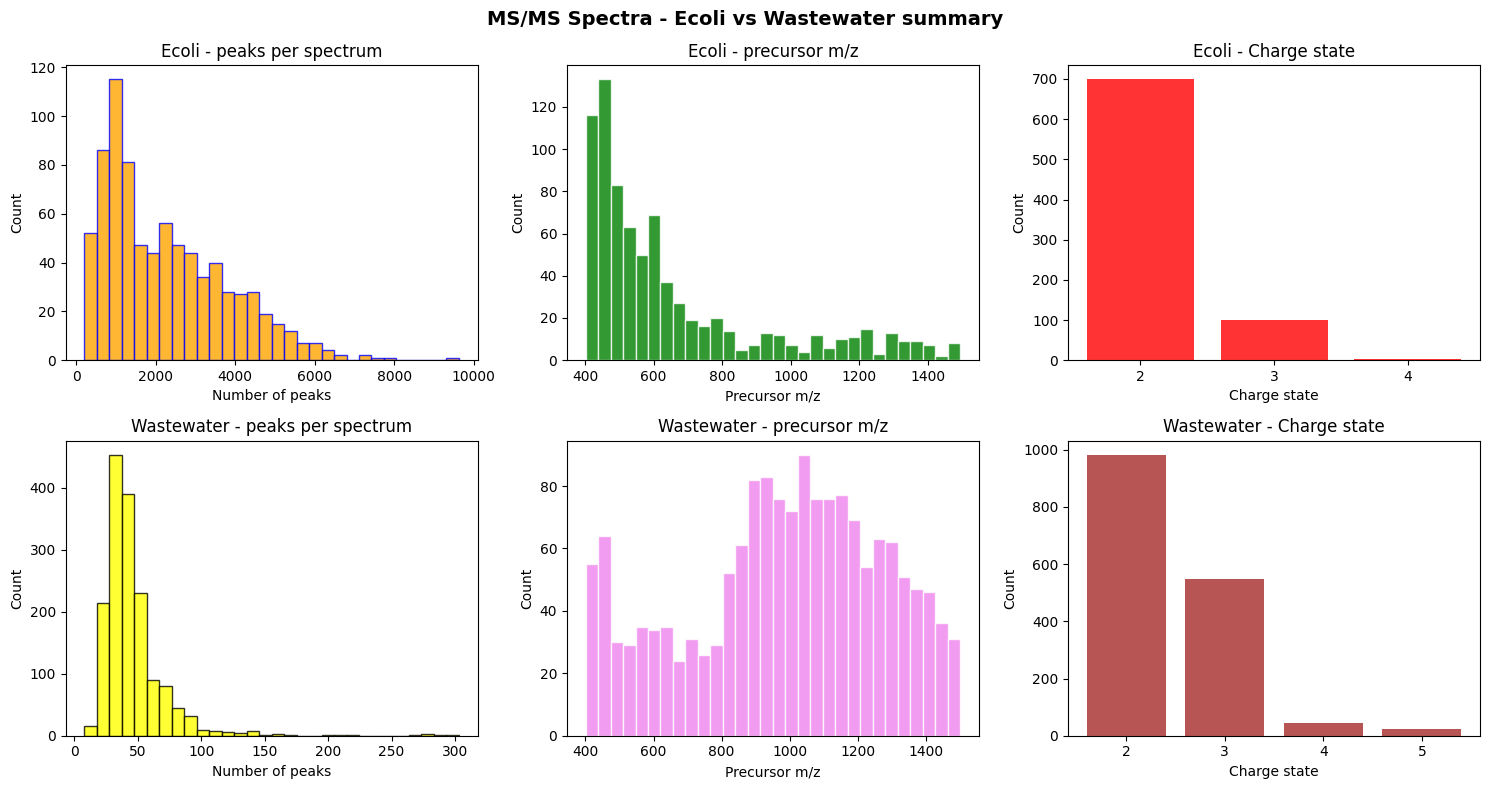

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('MS/MS Spectra - Ecoli vs Wastewater summary',
             fontsize=14, fontweight='bold')

axes[0,0].hist(ecoli_clean['num_peaks'], bins=30,
               color='orange', alpha=0.8, edgecolor='blue')
axes[0,0].set_title('Ecoli - peaks per spectrum')
axes[0,0].set_xlabel('Number of peaks')
axes[0,0].set_ylabel('Count')

axes[0,1].hist(ecoli_clean['precursor_mz'], bins=30,
               color='green', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Ecoli - precursor m/z')
axes[0,1].set_xlabel('Precursor m/z')
axes[0,1].set_ylabel('Count')

charge_ecoli = ecoli_clean['precursor_charge'].value_counts().sort_index()
axes[0,2].bar(charge_ecoli.index.astype(str), charge_ecoli.values,
              color='red', alpha=0.8)
axes[0,2].set_title('Ecoli - Charge state')
axes[0,2].set_xlabel('Charge state')
axes[0,2].set_ylabel('Count')

axes[1,0].hist(wastewater_clean['num_peaks'], bins=30,
               color='yellow', alpha=0.8, edgecolor='black')
axes[1,0].set_title('Wastewater - peaks per spectrum')
axes[1,0].set_xlabel('Number of peaks')
axes[1,0].set_ylabel('Count')

axes[1,1].hist(wastewater_clean['precursor_mz'], bins=30,
               color='violet', alpha=0.8, edgecolor='white')
axes[1,1].set_title('Wastewater - precursor m/z')
axes[1,1].set_xlabel('Precursor m/z')
axes[1,1].set_ylabel('Count')

charge_ww = wastewater_clean['precursor_charge'].value_counts().sort_index()
axes[1,2].bar(charge_ww.index.astype(str), charge_ww.values,
              color='brown', alpha=0.8)
axes[1,2].set_title('Wastewater - Charge state')
axes[1,2].set_xlabel('Charge state')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.show()

As per the graphs that I have plotted I have observed that the ecoli spectra are having high number of peaks that ranges between 500 to 2000 per spectrum whereas wastewater spectra is having very less 20 to 50 peaks per spectrum and this specifies that ecoli is more clean compared to wastewater.

In the m/z distribution, we have seen that ecoli peptides are concentrated more
in the low m/z range between 400 to 600 which specifies that the peptides are small whereas wastewater peptides vary in the range between 400 to 1500 and this specifies that wastewater is more diversed.

I have also noticed that both the datasets ecoli and wastewater are dominated by charge 2 but it seems like wastewater is having a bit more charge 3. Thus because of this reason wastewater contains large and much more complex peptides from diverse organisms rather than ecoli.

So in the initial steps of working with this dataset we have noticed that wastewater is more complex biological sample than ecoli. The low peak counts and wide m/z distribution are few reasons that makes wastewater more complex.

In [7]:
import time

In [ ]:
os.makedirs('/content/casanovo_output', exist_ok=True)

mzml_ecoli_1 = ecoli_path + 'Ecoli_EV_1.mzML'

start_time_1 = time.time()

!casanovo sequence \
    --output_dir /content/casanovo_output \
    --output_root casanovo_ecoli_ev1 \
    {mzml_ecoli_1}

total_time_1 = (time.time() - start_time_1) / 60

print(f"Ecoli EV sample 1 takes time: {total_time_1:.1f} minutes")
print(f"Result is saved to : /content/casanovo_output/")

INFO: Executed Command: /usr/local/bin/casanovo sequence --output_dir /content/casanovo_output --output_root casanovo_ecoli_ev1 /content/drive/MyDrive/peptide_project/Data/Ecoli/Ecoli_EV_1.mzML
INFO: Host Machine: 279d8bef6509
INFO: OS: Linux
INFO: OS Version: #1 SMP Mon Feb  2 12:27:57 UTC 2026
INFO: Python Version: 3.12.13
INFO: Casanovo Version: 5.1.2
INFO: Depthcharge Version: 0.4.9
INFO: PyTorch Version: 2.10.0+cu128
INFO: CUDA Version: 12.8
INFO: cuDNN Version: 91002
Seed set to 454
100% 548M/548M [00:19<00:00, 29.2MB/s]
INFO: Casanovo version 5.1.2
INFO: Sequencing peptides from:
INFO:   /content/drive/MyDrive/peptide_project/Data/Ecoli/Ecoli_EV_1.mzML
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Ecoli_EV_1.mzML: 100% 

I have run Casanovo de novo sequencing tool on the first Ecoli mzML file. It uses its pretrained transformer model weights to predict peptide sequences directly from the raw MS/MS spectra without using any reference database. Only 10842 spectra are successfully sequenced from a total of 17561 spectra as the remaining spectra were having insufficient quality and 37 spectra were skipped due to invalid precursor charge.

In [ ]:
mzml_ecoli_2 = ecoli_path + 'Ecoli_EV_2.mzML'

start_time_2 = time.time()

!casanovo sequence \
    --output_dir /content/casanovo_output \
    --output_root casanovo_ecoli_ev2 \
    {mzml_ecoli_2}

total_time_2 = (time.time() - start_time_2) / 60

print(f"Ecoli EV sample 2 takes time: {total_time_2:.1f} minutes")
print(f"Result is saved to : /content/casanovo_output/")

INFO: Executed Command: /usr/local/bin/casanovo sequence --output_dir /content/casanovo_output --output_root casanovo_ecoli_ev2 /content/drive/MyDrive/peptide_project/Data/Ecoli/Ecoli_EV_2.mzML
INFO: Host Machine: 279d8bef6509
INFO: OS: Linux
INFO: OS Version: #1 SMP Mon Feb  2 12:27:57 UTC 2026
INFO: Python Version: 3.12.13
INFO: Casanovo Version: 5.1.2
INFO: Depthcharge Version: 0.4.9
INFO: PyTorch Version: 2.10.0+cu128
INFO: CUDA Version: 12.8
INFO: cuDNN Version: 91002
Seed set to 454
INFO: Model weights file /root/.cache/casanovo/casanovo_v5_0_0_v5_0_0.ckpt retrieved from local cache
INFO: Casanovo version 5.1.2
INFO: Sequencing peptides from:
INFO:   /content/drive/MyDrive/peptide_project/Data/Ecoli/Ecoli_EV_2.mzML
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automaticall

The model weights were loaded from local cache in this second Ecoli mzML file which is faster than the previous Ecoli mzML file. The results are preety much similiar in both the mzML files and this shows the consistency of casanovo predictions. The median peptide length remains the same at 13 amino acids for both of the samples showing consistent tryptic digestion and the score distributions are almost same for both the samples which shows that the data quality is consistent.

In [ ]:
wastewater_samples = {
    'wastewater_Sample1_1.mzML' : 'casanovo_ww_s1_1',
    'wastewater_Sample1_2.mzML' : 'casanovo_ww_s1_2',
    'wastewater_Sample2_1.mzML' : 'casanovo_ww_s2_1',
    'wastewater_Sample2_2.mzML' : 'casanovo_ww_s2_2',
}

overall_start = time.time()

for sample_file, output_root in wastewater_samples.items():
    mzml_input = wastewater_path + sample_file

    sample_start = time.time()

    !casanovo sequence \
        --output_dir /content/casanovo_output \
        --output_root {output_root} \
        {mzml_input}

    sample_time = (time.time() - sample_start) / 60
    print(f"Wastewater sample completed in : {sample_time:.1f} minutes")

overall_time = (time.time() - overall_start) / 60

print(f"Wastewater sequencing completed in total time of : {overall_time:.1f} minutes")
print(f"Result is saved to : /content/casanovo_output/")

INFO: Executed Command: /usr/local/bin/casanovo sequence --output_dir /content/casanovo_output --output_root casanovo_ww_s1_1 /content/drive/MyDrive/peptide_project/Data/Wastewater/wastewater_Sample1_1.mzML
INFO: Host Machine: 279d8bef6509
INFO: OS: Linux
INFO: OS Version: #1 SMP Mon Feb  2 12:27:57 UTC 2026
INFO: Python Version: 3.12.13
INFO: Casanovo Version: 5.1.2
INFO: Depthcharge Version: 0.4.9
INFO: PyTorch Version: 2.10.0+cu128
INFO: CUDA Version: 12.8
INFO: cuDNN Version: 91002
Seed set to 454
INFO: Model weights file /root/.cache/casanovo/casanovo_v5_0_0_v5_0_0.ckpt retrieved from local cache
INFO: Casanovo version 5.1.2
INFO: Sequencing peptides from:
INFO:   /content/drive/MyDrive/peptide_project/Data/Wastewater/wastewater_Sample1_1.mzML
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metric

I have run casanovo on all the four wastewater mzML files. In the Ecoli samples, ground truth is available whereas wastewater samples contain unknown organisms so predictions will be evaluated using the False discovery rate rather than precision and recall. A total of 61023 peptide sequences predicted across the four wastewater samples. The data quality is good because only 126 spectra are skipped across all the four files which is less than 0.2% of the total spectra. Wastewater samples show high confidence scores compared to the ecoli samples. The median peptide length for all the wastewater samples is 11 amino acids whereas ecoli sample is having a median of 13 amino acids.

In [ ]:
def parse_casanovo_output(filepath):

    sequences = []
    scores = []
    scan_ids = []

    print(f"Parsing results from : {os.path.basename(filepath)}")

    with open(filepath, 'r') as file:
        for line in file:
            if line.startswith('COM') or \
               line.startswith('MTD') or \
               line.startswith('PSH') or \
               line.strip() == '':
                continue

            if line.startswith('PSM'):
                parts = line.strip().split('\t')
                if len(parts) >= 9:
                    sequences.append(parts[1])
                    scan_ids.append(parts[2])

                    try:
                        score = float(parts[8])
                    except (ValueError, IndexError):
                        score = 0.0
                    scores.append(score)

    result_df = pd.DataFrame({
        'scan_id' : scan_ids,
        'predicted_sequence' : sequences,
        'confidence_score' : scores
    })

    print(f"Total number of predictions detected: {len(result_df)}")
    print(f"Average confidence score achieved : {result_df['confidence_score'].mean():.4f}")
    return result_df

print("Parsing the Casanovo results for the Ecoli EV Samples")
print("-" * 60)

casanovo_ev1 = parse_casanovo_output(
    '/content/casanovo_output/casanovo_ecoli_ev1.mztab'
)
print()
casanovo_ev2 = parse_casanovo_output(
    '/content/casanovo_output/casanovo_ecoli_ev2.mztab'
)

casanovo_ecoli_combined = pd.concat(
    [casanovo_ev1, casanovo_ev2],
    ignore_index=True
)

print(f"\nAll of the combined Ecoli predictions : {len(casanovo_ecoli_combined)}")
print(f"First 5 predicted sequences:")
print(casanovo_ecoli_combined['predicted_sequence'].head().tolist())

Parsing the Casanovo results for the Ecoli EV Samples
------------------------------------------------------------
Parsing results from : casanovo_ecoli_ev1.mztab
Total number of predictions detected: 10842
Average confidence score achieved : -0.6466

Parsing results from : casanovo_ecoli_ev2.mztab
Total number of predictions detected: 10884
Average confidence score achieved : -0.6529

All of the combined Ecoli predictions : 21726
First 5 predicted sequences:
['FEFEEE', 'NQPSSRSSLKEA', 'CCGQCC', 'EGMDEDK', 'LGDRTEEAEEEK']


The parse function reads each of the PSM line from the mztab file and extracts the sequence from column 1 and the confidence score from the column 8. The average confidence score is negative at around -0.65 and this is quite normal for casanovo as it uses log probability scores where the value close to 0 indicate high confidence score and more negative values indicate low confidence score.

In [ ]:
print("Parsing the Casanovo results for the Wastewater samples")
print("-" * 55)

wastewater_output_files = [
    '/content/casanovo_output/casanovo_ww_s1_1.mztab',
    '/content/casanovo_output/casanovo_ww_s1_2.mztab',
    '/content/casanovo_output/casanovo_ww_s2_1.mztab',
    '/content/casanovo_output/casanovo_ww_s2_2.mztab',
]

ww_results_list = []

for output_file in wastewater_output_files:
    ww_df = parse_casanovo_output(output_file)
    ww_results_list.append(ww_df)
    print()

casanovo_ww_combined = pd.concat(
    ww_results_list,
    ignore_index=True
)

print(f"All the combined Wastewater predictions : {len(casanovo_ww_combined)}")
print(f"First 5 predicted sequences:")
print(casanovo_ww_combined['predicted_sequence'].head().tolist())

Parsing the Casanovo results for the Wastewater samples
-------------------------------------------------------
Parsing results from : casanovo_ww_s1_1.mztab
Total number of predictions detected: 17073
Average confidence score achieved : -0.2894

Parsing results from : casanovo_ww_s1_2.mztab
Total number of predictions detected: 17562
Average confidence score achieved : -0.2436

Parsing results from : casanovo_ww_s2_1.mztab
Total number of predictions detected: 16106
Average confidence score achieved : -0.3437

Parsing results from : casanovo_ww_s2_2.mztab
Total number of predictions detected: 10282
Average confidence score achieved : -0.3021

All the combined Wastewater predictions : 61023
First 5 predicted sequences:
['LAEEEEYEDLLK', 'DSSEYLLLSPLK', 'YGLTTLQLEELLK', 'EDDDSLLSLLK', 'PLGAEDLLSLLEK']


I have observed that the wastewater confidence scores are higher than the ecoli which means that casanovo is more confident on wastewater predictions. Wastewater predicted sequences seems to appear longer and more complex than the ecoli sequences which highlights my previous observation that wastewater contains more diverse peptide types. The wastewater predictions are high as compared to the ecoli predictions because wastewater has more spectra and diversed organisms present in the sample.

In [ ]:
def aa_level_evaluation(predicted, true_sequence):

    pred = list(str(predicted))
    true = list(str(true_sequence))

    min_len = min(len(pred), len(true))
    matches = sum(1 for i in range(min_len) if pred[i] == true[i])

    precision = matches / len(pred) if len(pred) > 0 else 0
    recall = matches / len(true) if len(true) > 0 else 0

    return precision, recall

def peptide_level_evaluation(predicted, true_sequence):

    return 1 if str(predicted).strip() == str(true_sequence).strip() else 0

In [ ]:
ground_truth_seq = ecoli_clean_df['Sequence'].dropna().tolist()
casanovo_pred_seq = casanovo_ecoli_combined['predicted_sequence'].tolist()

aa_precision_scores = []
aa_recall_scores = []
peptide_match_scores = []

total_evaluated = min(len(casanovo_pred_seq), len(ground_truth_seq))

print("Evaluation of the Casanovo predictions on Ecoli dataset")
print("-" * 45)
print(f"Total number of predictions that is evaluated : {total_evaluated}")

for i in range(total_evaluated):
    pred = str(casanovo_pred_seq[i])
    true = str(ground_truth_seq[i])

    precision, recall = aa_level_evaluation(pred, true)
    aa_precision_scores.append(precision)
    aa_recall_scores.append(recall)

    peptide_match_scores.append(peptide_level_evaluation(pred, true))

casanovo_aa_precision = sum(aa_precision_scores) / len(aa_precision_scores)
casanovo_aa_recall = sum(aa_recall_scores) / len(aa_recall_scores)
casanovo_peptide_acc = sum(peptide_match_scores) / len(peptide_match_scores)

print(f"\nCasanovo evaluation results achieved on the Ecoli dataset:")
print(f"-" * 50)
print(f"Total number of predictions evaluated : {total_evaluated}")
print(f"Amino Acid precision : {casanovo_aa_precision:.4f} ({casanovo_aa_precision*100:.2f}%)")
print(f"Amino Acid recall : {casanovo_aa_recall:.4f} ({casanovo_aa_recall*100:.2f}%)")
print(f"Peptide level accuracy : {casanovo_peptide_acc:.4f} ({casanovo_peptide_acc*100:.2f}%)")

Evaluation of the Casanovo predictions on Ecoli dataset
---------------------------------------------
Total number of predictions that is evaluated : 3162

Casanovo evaluation results achieved on the Ecoli dataset:
--------------------------------------------------
Total number of predictions evaluated : 3162
Amino Acid precision : 0.0544 (5.44%)
Amino Acid recall : 0.0533 (5.33%)
Peptide level accuracy : 0.0000 (0.00%)


The Amino acid precision of 5.44% shows that out of all the amino acids predicted by the casanovo only 5.44% matches the correct amino acid at the correct position. Amino acid recall of 5.33% shows that the casanovo recovered only 5.33% of the true amino acids correctly. Peptide level accuracy of 0.00% shows that no complete peptide sequence was predicted exactly correct.

In [ ]:
def calculate_fdr(confidence_scores, fdr_threshold=0.05):

    scores = list(confidence_scores)
    total  = len(scores)

    low_confidence_count = sum(1 for s in scores if s < fdr_threshold)

    fdr_estimate = low_confidence_count / total if total > 0 else 0

    return fdr_estimate

In [ ]:
ww_confidence_scores = casanovo_ww_combined['confidence_score'].tolist()

casanovo_ww_fdr = calculate_fdr(ww_confidence_scores)

print("FDR Estimation for the Wastewater dataset")
print("-" * 45)
print(f"Total number of Wastewater predictions : {len(ww_confidence_scores)}")
print(f"Average confidence score achieved : {sum(ww_confidence_scores)/len(ww_confidence_scores):.4f}")
print(f"Predictions that is scored below 0.05 : {sum(1 for s in ww_confidence_scores if s < 0.05)}")
print(f"Estimated FDR : {casanovo_ww_fdr:.4f} ({casanovo_ww_fdr*100:.2f}%)")

FDR Estimation for the Wastewater dataset
---------------------------------------------
Total number of Wastewater predictions : 61023
Average confidence score achieved : -0.2927
Predictions that is scored below 0.05 : 40137
Estimated FDR : 0.6577 (65.77%)


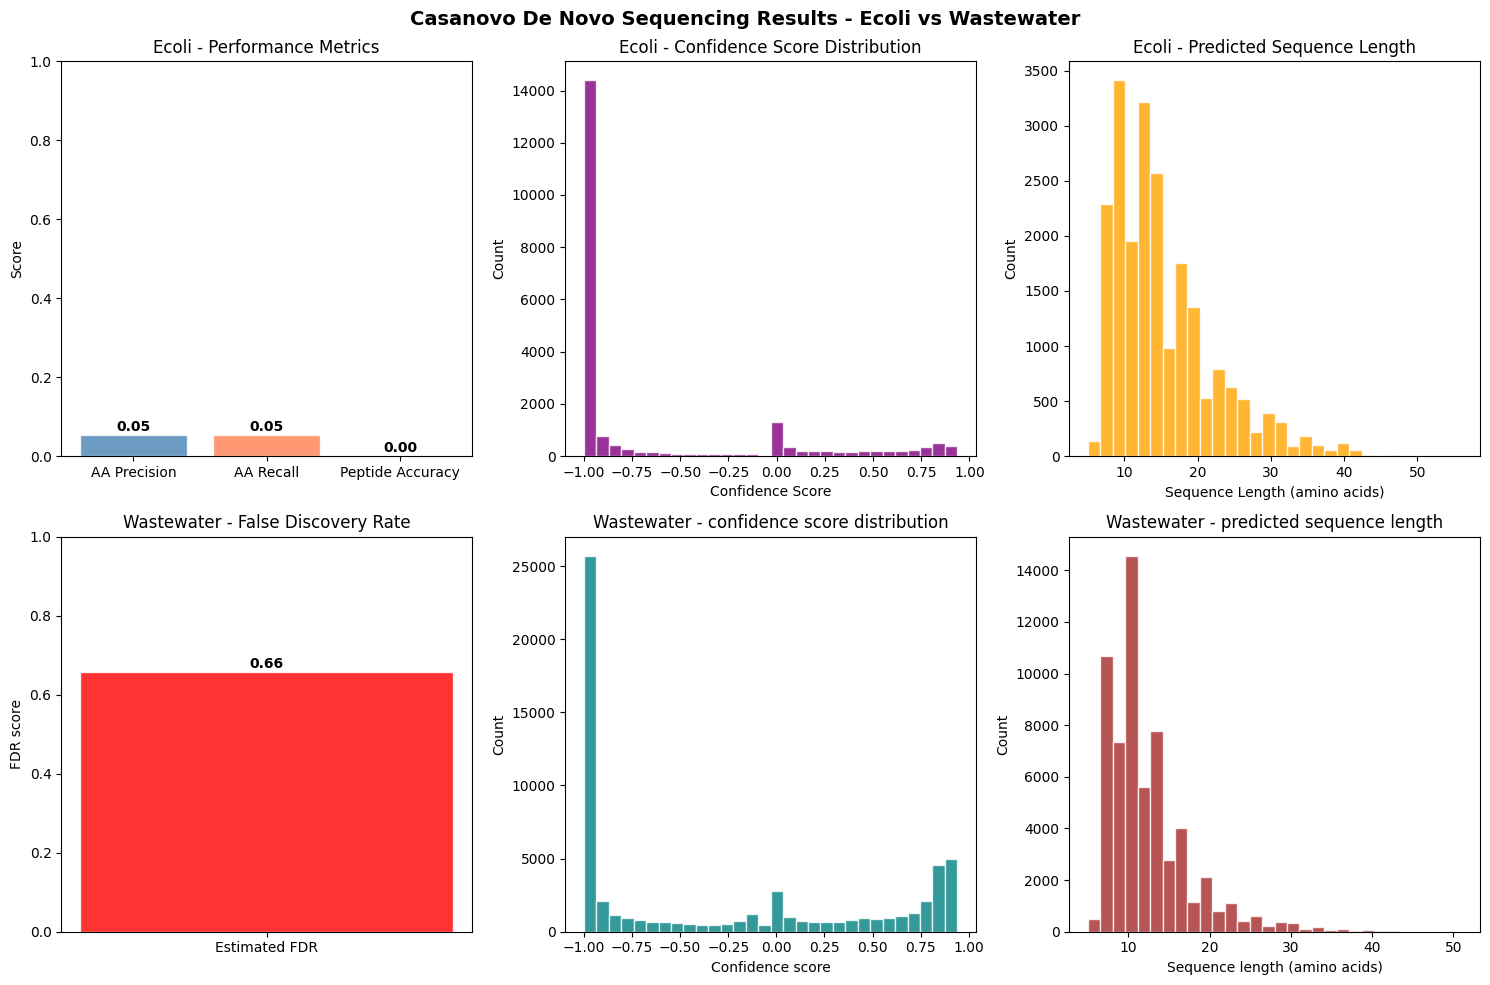

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Casanovo De Novo Sequencing Results - Ecoli vs Wastewater',
             fontsize=14, fontweight='bold')

metrics = ['AA Precision', 'AA Recall', 'Peptide Accuracy']                               #Ecoli Performance Metrics
values = [casanovo_aa_precision, casanovo_aa_recall, casanovo_peptide_acc]
colors = ['steelblue', 'coral', 'green']

axes[0,0].bar(metrics, values, color=colors, alpha=0.8, edgecolor='white')
axes[0,0].set_title('Ecoli - Performance Metrics')
axes[0,0].set_ylabel('Score')
axes[0,0].set_ylim(0, 1)
for i, v in enumerate(values):
    axes[0,0].text(i, v + 0.01, f'{v:.2f}',
                   ha='center', fontweight='bold')

axes[0,1].hist(casanovo_ecoli_combined['confidence_score'],                                 #Ecoli Confidence Score Distribution
               bins=30, color='purple', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Ecoli - Confidence Score Distribution')
axes[0,1].set_xlabel('Confidence Score')
axes[0,1].set_ylabel('Count')

ecoli_seq_lengths = casanovo_ecoli_combined['predicted_sequence'].apply(len)                #Ecoli Predicted Sequence Length Distribution
axes[0,2].hist(ecoli_seq_lengths, bins=30,
               color='orange', alpha=0.8, edgecolor='white')
axes[0,2].set_title('Ecoli - Predicted Sequence Length')
axes[0,2].set_xlabel('Sequence Length (amino acids)')
axes[0,2].set_ylabel('Count')

axes[1,0].bar(['Estimated FDR'], [casanovo_ww_fdr],                         #Wastewater results achieved
               color='red', alpha=0.8, edgecolor='white')
axes[1,0].set_title('Wastewater - False Discovery Rate')
axes[1,0].set_ylabel('FDR score')
axes[1,0].set_ylim(0, 1)
axes[1,0].text(0, casanovo_ww_fdr + 0.01,
               f'{casanovo_ww_fdr:.2f}',
               ha='center', fontweight='bold')

axes[1,1].hist(casanovo_ww_combined['confidence_score'],                             #Wastewater Confidence Score Distribution
               bins=30, color='teal', alpha=0.8, edgecolor='white')
axes[1,1].set_title('Wastewater - confidence score distribution')
axes[1,1].set_xlabel('Confidence score')
axes[1,1].set_ylabel('Count')

ww_seq_lengths = casanovo_ww_combined['predicted_sequence'].apply(len)               #Wastewater Predicted Sequence Length Distribution
axes[1,2].hist(ww_seq_lengths, bins=30,
               color='brown', alpha=0.8, edgecolor='white')
axes[1,2].set_title('Wastewater - predicted sequence length')
axes[1,2].set_xlabel('Sequence length (amino acids)')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.show()

I have visualized the Casanovo tool result for the Ecoli and the Wastewater dataset and have observed that most of the predictions have very low confidence score near -1.0 for both Ecoli and the Wastewater.

The wastewater FDR achieved is 66% and this was expected because wastewater contains completely unknown organisms.

The peptide length distributions seems to be similar for both the datasets confirming the consistent prediction behavior.

The performance metrics is low because de novo sequencing predicts sequences without any database reference making the exact matches very rare.

Novor Sequencing tool

In [ ]:
!apt-get install -y default-jre -q

!wget "http://genesis.ugent.be/maven2/com/compomics/denovogui/DeNovoGUI/1.15.11/DeNovoGUI-1.15.11-mac_and_linux.tar.gz" \
     -O /content/denovogui.tar.gz

!tar -xzf /content/denovogui.tar.gz -C /content/

import os
print("Files extracted:")
for f in os.listdir('/content/DeNovoGUI-1.15.11'):
    print(f"- {f}")

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  at-spi2-core default-jre-headless fonts-dejavu-core fonts-dejavu-extra
  gsettings-desktop-schemas libatk-bridge2.0-0 libatk-wrapper-java
  libatk-wrapper-java-jni libatk1.0-0 libatk1.0-data libatspi2.0-0
  libxcomposite1 libxtst6 libxxf86dga1 openjdk-11-jre openjdk-11-jre-headless
  session-migration x11-utils
Suggested packages:
  libnss-mdns fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  | fonts-wqy-zenhei fonts-indic mesa-utils
The following NEW packages will be installed:
  at-spi2-core default-jre default-jre-headless fonts-dejavu-core
  fonts-dejavu-extra gsettings-desktop-schemas libatk-bridge2.0-0
  libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0 libatk1.0-data
  libatspi2.0-0 libxcomposite1 libxtst6 libxxf86dga1 openjdk-11-jre
  openjdk-11-jre-headless session-migration x11-utils
0 upgraded, 19 newly installed, 0 to r

In [ ]:
novor_jar = None

for root, dirs, files in os.walk('/content/DeNovoGUI-1.15.11'):
    for f in files:
        if 'novor' in f.lower() and f.endswith('.jar'):
            novor_jar = os.path.join(root, f)
            print(f"Novor jar found : {novor_jar}")

if novor_jar is None:
    print("Novor jar not found - checking all jar files:")
    for root, dirs, files in os.walk('/content/DeNovoGUI-1.15.11'):
        for f in files:
            if f.endswith('.jar'):
                print(f" - {os.path.join(root, f)}")

Novor jar found : /content/DeNovoGUI-1.15.11/resources/Novor/novor.jar


In [ ]:
novor_jar = '/content/DeNovoGUI-1.15.11/resources/Novor/novor.jar'

import os
if os.path.exists(novor_jar):
    size = os.path.getsize(novor_jar) / (1024*1024)
    print(f"Novor jar found : {novor_jar}")
    print(f"Novor jar size : {size:.1f} MB")
    print(f"Novor is ready")

Novor jar found : /content/DeNovoGUI-1.15.11/resources/Novor/novor.jar
Novor jar size : 1.9 MB
Novor is ready


In [ ]:
novor_params = """# Novor parameter file
enzyme = Trypsin
fragmentation = HCD
massAnalyzer = FT
fragmentIonErrorTol = 0.01Da
precursorErrorTol = 15ppm
variableModifications = Oxidation (M)
fixedModifications = Carbamidomethyl (C)
forbiddenResidues = I
"""
with open('/content/novor_params.txt', 'w') as f:
    f.write(novor_params)

print("Novor parameter file is created")
print("Parameters set:")
print("Enzyme : Trypsin")
print("Fragmentation : HCD")
print("Mass analyzer : FT")
print("Fragment ion error : 0.01 Da")
print("Precursor error : 15 ppm")
print("Variable mods : Oxidation (M)")
print("Fixed mods : Carbamidomethyl (C)")

Novor parameter file is created
Parameters set:
Enzyme : Trypsin
Fragmentation : HCD
Mass analyzer : FT
Fragment ion error : 0.01 Da
Precursor error : 15 ppm
Variable mods : Oxidation (M)
Fixed mods : Carbamidomethyl (C)


I have used a parameter file to deal with the experimental settings used during mass spectrometry data collection as Novor is a Java based tool which uses a rule based scoring approach so it needs to be aware of the experimental conditions to correctly calculate the peptide mass and score.

In [ ]:
from pyteomics import mzml, mgf

os.makedirs('/content/novor_output', exist_ok=True)

def convert_mzml_to_mgf(mzml_filepath, mgf_filepath):

    spectra_list = []

    with mzml.MzML(mzml_filepath) as reader:
        for spectrum in reader:
            if spectrum.get('ms level', 0) == 2:
                if 'precursorList' in spectrum:
                    prec = spectrum['precursorList']['precursor'][0]
                    sel_ion = prec['selectedIonList']['selectedIon'][0]
                    precursor_mz = sel_ion.get('selected ion m/z', 0)
                    precursor_charge = int(sel_ion.get('charge state', 2))

                    spectra_list.append({
                        'params': {
                            'title' : spectrum['id'],
                            'pepmass' : (precursor_mz, None),
                            'charge' : [precursor_charge],
                        },
                        'm/z array' : spectrum['m/z array'],
                        'intensity array' : spectrum['intensity array'],
                    })

    mgf.write(spectra_list, mgf_filepath)
    return len(spectra_list)

mzml_ecoli_1 = ecoli_path + 'Ecoli_EV_1.mzML'
mgf_ecoli_1 = '/content/novor_output/ecoli_ev1.mgf'

print("Converting Ecoli EV 1 from mzML to MGF")                            #Here I am converting Ecoli EV 1
count_1 = convert_mzml_to_mgf(mzml_ecoli_1, mgf_ecoli_1)
print(f"Ecoli EV 1 converted : {count_1} spectra")

Converting Ecoli EV 1 from mzML to MGF
Ecoli EV 1 converted : 10881 spectra


Novor uses MGF as input rather than mzML format and this is the reason I have converted the mzML files to MGF format before running the Novor tool and I ahve observed that only the MS2 level spectra were extracted during the conversion as these are the tandem MS/MS spectra needed for de novo peptide sequencing.

In [ ]:
mzml_ecoli_2 = ecoli_path + 'Ecoli_EV_2.mzML'                               #Here I am converting Ecoli EV 2
mgf_ecoli_2 = '/content/novor_output/ecoli_ev2.mgf'

print("Converting Ecoli EV 2 from mzML to MGF")
count_2 = convert_mzml_to_mgf(mzml_ecoli_2, mgf_ecoli_2)
print(f"Ecoli EV 2 is converted : {count_2} spectra")

Converting Ecoli EV 2 from mzML to MGF
Ecoli EV 2 is converted : 10924 spectra


In [ ]:
wastewater_files_mgf = {
    'wastewater_Sample1_1.mzML' : '/content/novor_output/ww_s1_1.mgf',
    'wastewater_Sample1_2.mzML' : '/content/novor_output/ww_s1_2.mgf',                             #Here I am defining all the wastewater files
    'wastewater_Sample2_1.mzML' : '/content/novor_output/ww_s2_1.mgf',
    'wastewater_Sample2_2.mzML' : '/content/novor_output/ww_s2_2.mgf',
}

print("Converting all Wastewater files from mzML to MGF")

for sample_file, mgf_output in wastewater_files_mgf.items():
    mzml_input = wastewater_path + sample_file
    count = convert_mzml_to_mgf(mzml_input, mgf_output)
    print(f"{sample_file} converted : {count} spectra")

print("\nAll of the wastewater files are converted successfully")

Converting all Wastewater files from mzML to MGF
wastewater_Sample1_1.mzML converted : 17100 spectra
wastewater_Sample1_2.mzML converted : 17600 spectra
wastewater_Sample2_1.mzML converted : 16144 spectra
wastewater_Sample2_2.mzML converted : 10306 spectra

All of the wastewater files are converted successfully


In [ ]:
os.makedirs('/content/novor_output/ecoli_ev1_results', exist_ok=True)

print("Running Novor on Ecoli EV sample 1")
start_time_1 = time.time()

!java -jar {novor_jar} \
    -p /content/novor_params.txt \
    -f /content/novor_output/ecoli_ev1.mgf \
    -o /content/novor_output/ecoli_ev1_results

total_time_1 = (time.time() - start_time_1) / 60
print(f"Ecoli EV Sample 1 completed in : {total_time_1:.1f} minutes")
print(f"Results saved in : /content/novor_output/ecoli_ev1_results")

Running Novor on Ecoli EV sample 1

MMMMMMMMMMMMMMMMMMMMMMMMW0xolcldOWMMMMMMMMMMMMMMMM
MMMMMMMMMMMMMMXkdllclodl:;;;;;;;;:oOWMMMMMMMMMMMMM
MMMMMMMMMMMM0c;;;;;;;;;;;;;;;;;;;;;;cKMMMMMMMMMMMM
MMMMMMMMMMMd;;;;;;;;;;;;;;;;;;;;;;;;;;k0KXWMMMMMMM
MMMMMMMWXXk;;;;;;;;;;;;;;;;;;;;;;;;;:;;;;;;cxNMMMM
MMMWOoc;;;;;;;;;;;;;;;;;;;;;;;;:oxol:;;;;;;;;:kMMM
MMO:;;;;;;;;;;;:dOXKxc;;;;;lx0NKd:;;;;;;;;;;;;;kMM
MO;;;;;;;;;:lkXMMMMMMMXkkKWMXx:;;;;;;;;;;;;;;;;;NM
Ml;;;;;;:d0WMMMMMKocOWMMMNkc;;;;;;;;;;;;;;;;;;;;OM
Mx;;;cxKWMMMMMWOc;;;;:xOo;;;;;;;;;;;;;;;;;;;;;;;0M
MWoxXMMMMMMMNx:;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;oMM
MMMMMMMMMMWd:;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;:o0MMM
MMMMMMMMMM0c:::::::::::;;;;;;;;;;;:::::::coONMMMMM
#=================== N-O-V-O-R ===================
#   NOVOR: Real-time Peptide de Novo Sequencing   
#              v1.05.0573 (stable)
#             Free Academic License               
#============== www.rapidnovor.org ===============
#
# This free academic license can be used for educational and

Novor uses a real time scoring algorithm based on the amino acid and di-amino acid models to predict peptide sequences directly the from MS/MS spectra. The time taken by Novor for processing the spectra is fast as compared to the casanovo tool.

In [ ]:
os.makedirs('/content/novor_output/ecoli_ev2_results', exist_ok=True)

print("Running Novor on Ecoli EV sample 2")
start_time_2 = time.time()

!java -jar {novor_jar} \
    -p /content/novor_params.txt \
    -f /content/novor_output/ecoli_ev2.mgf \
    -o /content/novor_output/ecoli_ev2_results

total_time_2 = (time.time() - start_time_2) / 60
print(f"Ecoli EV sample 2 is completed in : {total_time_2:.1f} minutes")
print(f"Results saved in : /content/novor_output/ecoli_ev2_results")

Running Novor on Ecoli EV sample 2

MMMMMMMMMMMMMMMMMMMMMMMMW0xolcldOWMMMMMMMMMMMMMMMM
MMMMMMMMMMMMMMXkdllclodl:;;;;;;;;:oOWMMMMMMMMMMMMM
MMMMMMMMMMMM0c;;;;;;;;;;;;;;;;;;;;;;cKMMMMMMMMMMMM
MMMMMMMMMMMd;;;;;;;;;;;;;;;;;;;;;;;;;;k0KXWMMMMMMM
MMMMMMMWXXk;;;;;;;;;;;;;;;;;;;;;;;;;:;;;;;;cxNMMMM
MMMWOoc;;;;;;;;;;;;;;;;;;;;;;;;:oxol:;;;;;;;;:kMMM
MMO:;;;;;;;;;;;:dOXKxc;;;;;lx0NKd:;;;;;;;;;;;;;kMM
MO;;;;;;;;;:lkXMMMMMMMXkkKWMXx:;;;;;;;;;;;;;;;;;NM
Ml;;;;;;:d0WMMMMMKocOWMMMNkc;;;;;;;;;;;;;;;;;;;;OM
Mx;;;cxKWMMMMMWOc;;;;:xOo;;;;;;;;;;;;;;;;;;;;;;;0M
MWoxXMMMMMMMNx:;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;oMM
MMMMMMMMMMWd:;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;:o0MMM
MMMMMMMMMM0c:::::::::::;;;;;;;;;;;:::::::coONMMMMM
#=================== N-O-V-O-R ===================
#   NOVOR: Real-time Peptide de Novo Sequencing   
#              v1.05.0573 (stable)
#             Free Academic License               
#============== www.rapidnovor.org ===============
#
# This free academic license can be used for educational and

In [ ]:
wastewater_mgf_files = {
    'ww_s1_1.mgf' : 'ww_s1_1_results',
    'ww_s1_2.mgf' : 'ww_s1_2_results',
    'ww_s2_1.mgf' : 'ww_s2_1_results',
    'ww_s2_2.mgf' : 'ww_s2_2_results',
}

overall_start = time.time()

for mgf_file, output_name in wastewater_mgf_files.items():
    mgf_input = f'/content/novor_output/{mgf_file}'
    novor_out = f'/content/novor_output/{output_name}'
    os.makedirs(novor_out, exist_ok=True)

    sample_start = time.time()

    !java -jar {novor_jar} \
        -p /content/novor_params.txt \
        -f {mgf_input} \
        -o {novor_out}

    sample_time = (time.time() - sample_start) / 60
    print(f"{mgf_file} completed in : {sample_time:.1f} minutes")

overall_time = (time.time() - overall_start) / 60
print(f"\nAll wastewater samples completed in : {overall_time:.1f} minutes")
print(f"Results saved in : /content/novor_output/")


MMMMMMMMMMMMMMMMMMMMMMMMW0xolcldOWMMMMMMMMMMMMMMMM
MMMMMMMMMMMMMMXkdllclodl:;;;;;;;;:oOWMMMMMMMMMMMMM
MMMMMMMMMMMM0c;;;;;;;;;;;;;;;;;;;;;;cKMMMMMMMMMMMM
MMMMMMMMMMMd;;;;;;;;;;;;;;;;;;;;;;;;;;k0KXWMMMMMMM
MMMMMMMWXXk;;;;;;;;;;;;;;;;;;;;;;;;;:;;;;;;cxNMMMM
MMMWOoc;;;;;;;;;;;;;;;;;;;;;;;;:oxol:;;;;;;;;:kMMM
MMO:;;;;;;;;;;;:dOXKxc;;;;;lx0NKd:;;;;;;;;;;;;;kMM
MO;;;;;;;;;:lkXMMMMMMMXkkKWMXx:;;;;;;;;;;;;;;;;;NM
Ml;;;;;;:d0WMMMMMKocOWMMMNkc;;;;;;;;;;;;;;;;;;;;OM
Mx;;;cxKWMMMMMWOc;;;;:xOo;;;;;;;;;;;;;;;;;;;;;;;0M
MWoxXMMMMMMMNx:;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;oMM
MMMMMMMMMMWd:;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;:o0MMM
MMMMMMMMMM0c:::::::::::;;;;;;;;;;;:::::::coONMMMMM
#=================== N-O-V-O-R ===================
#   NOVOR: Real-time Peptide de Novo Sequencing   
#              v1.05.0573 (stable)
#             Free Academic License               
#============== www.rapidnovor.org ===============
#
# This free academic license can be used for educational and academic research purposes only.



Novor tool processed the wastewater spectra faster than the ecoli spectra because the wastewater spectra are simple with few peaks per spectrum as observed in my preprocessing plots. Here also Novor completed the files very fast compared to the casanovo for the same files.

In [ ]:
def parse_novor_output(filepath):

    sequences = []
    scores = []
    scan_ids = []

    print(f"Parsing the results from : {os.path.basename(filepath)}")

    with open(filepath, 'r') as file:
        for line in file:
            if line.startswith('#') or line.strip() == '':
                continue
            parts = line.strip().split(',')
            if len(parts) >= 10:
                scan_ids.append(parts[0].strip())
                sequences.append(parts[9].strip())
                try:
                    score = float(parts[8].strip())
                except (ValueError, IndexError):
                    score = 0.0
                scores.append(score)

    result_df = pd.DataFrame({
        'scan_id' : scan_ids,
        'predicted_sequence' : sequences,
        'confidence_score' : scores
    })

    print(f"Total predictions found : {len(result_df)}")
    print(f"Average confidence score : {result_df['confidence_score'].mean():.4f}")
    return result_df

print("Parsing Novor results for Ecoli EV Samples")
print("-" * 45)

novor_ev1 = parse_novor_output('/content/novor_output/ecoli_ev1_results')
print()
novor_ev2 = parse_novor_output('/content/novor_output/ecoli_ev2_results')

#Here I am combining both the Ecoli results
novor_ecoli_combined = pd.concat(
    [novor_ev1, novor_ev2],
    ignore_index=True
)
print(f"\nCombined predictions of Novor ecoli : {len(novor_ecoli_combined)}")
print(f"First 5 predicted sequences:")
print(novor_ecoli_combined['predicted_sequence'].head().tolist())

Parsing Novor results for Ecoli EV Samples
---------------------------------------------
Parsing the results from : ecoli_ev1_results
Total predictions found : 10841
Average confidence score : 36.0349

Parsing the results from : ecoli_ev2_results
Total predictions found : 10891
Average confidence score : 35.7932

Combined predictions of Novor ecoli : 21732
First 5 predicted sequences:
['WC(Cam)DDAQLGLPK', 'QUEEUHHUGR', 'NSGC(Cam)AWUUUUR', 'RHVLLLFR', 'M(O)LKKKKLWAR']


I have parsed both the ecoli files which shows a combined total of 21732 predicted peptide sequences. The average confidence score of around 36 out of 100 specifies moderate confidence in the predictions.

Novor uses a 0 to 100 scoring scale where high scores indicate more confident predictions. The combined predictions will now be evaluated against the 3162 ground truth sequences from the excel files.


In [ ]:
print("Parsing novor results for Wastewater samples")
print("-" * 55)

novor_ww_files = [
    '/content/novor_output/ww_s1_1_results',
    '/content/novor_output/ww_s1_2_results',
    '/content/novor_output/ww_s2_1_results',
    '/content/novor_output/ww_s2_2_results',
]

novor_ww_list = []

for output_file in novor_ww_files:
    ww_df = parse_novor_output(output_file)
    novor_ww_list.append(ww_df)
    print()

#Here I am combining all the wastewater results
novor_ww_combined = pd.concat(
    novor_ww_list,
    ignore_index=True
)

print(f"Combined predictions of Novor wastewater : {len(novor_ww_combined)}")
print(f"First 5 predicted sequences:")
print(novor_ww_combined['predicted_sequence'].head().tolist())

Parsing novor results for Wastewater samples
-------------------------------------------------------
Parsing the results from : ww_s1_1_results
Total predictions found : 17085
Average confidence score : 47.5185

Parsing the results from : ww_s1_2_results
Total predictions found : 17584
Average confidence score : 49.7883

Parsing the results from : ww_s2_1_results
Total predictions found : 16125
Average confidence score : 45.6137

Parsing the results from : ww_s2_2_results
Total predictions found : 10287
Average confidence score : 46.3083

Combined predictions of Novor wastewater : 61081
First 5 predicted sequences:
['UC(Cam)FEUC(Cam)PAM(O)GR', 'ELHMQUTUDR', 'SUTGWWGSGPUDK', 'M(O)VAEUSPSWR', 'SGDSVHGEUWPR']


 The average confidence score of the wastewater is high as compared to the average of the ecoli which shows that Novor is more confident on wastewater spectra rather than the ecoli spectra.

 The wastewater sequences contain more number of unknown amino acids represented by U compared to the ecoli sequences reflecting the higher complexity of the environmental samples.

In [ ]:
novor_pred_seq = novor_ecoli_combined['predicted_sequence'].tolist()

#This is the lists I am creating to store the evaluation scores
novor_aa_precision_scores = []
novor_aa_recall_scores = []
novor_peptide_match_scores = []

total_evaluated = min(len(novor_pred_seq), len(ground_truth_seq))

print("Evaluating Novor predictions on Ecoli dataset")
print("-" * 45)
print(f"Total predictions to evaluate : {total_evaluated}")

for i in range(total_evaluated):
    pred = str(novor_pred_seq[i])
    true = str(ground_truth_seq[i])

    precision, recall = aa_level_evaluation(pred, true)
    novor_aa_precision_scores.append(precision)
    novor_aa_recall_scores.append(recall)
    novor_peptide_match_scores.append(peptide_level_evaluation(pred, true))

#Here I am calculating the final scores
novor_aa_precision = sum(novor_aa_precision_scores) / len(novor_aa_precision_scores)
novor_aa_recall = sum(novor_aa_recall_scores) / len(novor_aa_recall_scores)
novor_peptide_acc = sum(novor_peptide_match_scores) / len(novor_peptide_match_scores)

print(f"\nNovor evaluation results on Ecoli dataset:")
print(f"-" * 45)
print(f"Total predictions evaluated : {total_evaluated}")
print(f"Amino Acid Precision : {novor_aa_precision:.4f} ({novor_aa_precision*100:.2f}%)")
print(f"Amino Acid Recall : {novor_aa_recall:.4f} ({novor_aa_recall*100:.2f}%)")
print(f"Peptide Level Accuracy : {novor_peptide_acc:.4f} ({novor_peptide_acc*100:.2f}%)")

Evaluating Novor predictions on Ecoli dataset
---------------------------------------------
Total predictions to evaluate : 3162

Novor evaluation results on Ecoli dataset:
---------------------------------------------
Total predictions evaluated : 3162
Amino Acid Precision : 0.0478 (4.78%)
Amino Acid Recall : 0.0471 (4.71%)
Peptide Level Accuracy : 0.0000 (0.00%)


The novor amino acid shows a precision of 4.78% which means that out of all the amino acids predicted only 4.78% matches the correct amino acid at the correct position.

The novor amino acid shows a recall of 4.71% which means that novor recovered only 4.71% of the true amino acids correctly.

The novor peptide level accuracy of 0.00% means no complete peptide sequence was predicted exactly correctly.

In [ ]:
novor_ww_scores = novor_ww_combined['confidence_score'].tolist()

#Here I am calculating the FDR for Novor wastewater predictions
novor_fdr_threshold = 50
low_confidence = sum(1 for s in novor_ww_scores if s < novor_fdr_threshold)
novor_ww_fdr = low_confidence / len(novor_ww_scores)

print("FDR Estimation for Novor Wastewater dataset")
print("-" * 45)
print(f"Total wastewater predictions : {len(novor_ww_scores)}")
print(f"Average confidence score achieved : {sum(novor_ww_scores)/len(novor_ww_scores):.4f}")
print(f"Predictions scored below 50 : {low_confidence}")
print(f"Estimated FDR : {novor_ww_fdr:.4f} ({novor_ww_fdr*100:.2f}%)")

FDR Estimation for Novor Wastewater dataset
---------------------------------------------
Total wastewater predictions : 61081
Average confidence score achieved : 47.4653
Predictions scored below 50 : 33912
Estimated FDR : 0.5552 (55.52%)


I have estimated the False Discovery Rate for novor wastewater predictions by using a confidence score threshold of 50. Novor estimated the FDR of 55.52% which means that out of the 61081 wastewater predictions approximately 33912 are likely to be the false discoveries.

The Novor FDR of 55.52% is lower than the casanovo FDR of 66% which makes  Novor predictions more confident on the wastewater samples.

The average confidence score of 47.47 is just below the threshold of 50 which shows why more than half of the predictions fall below the threshold.

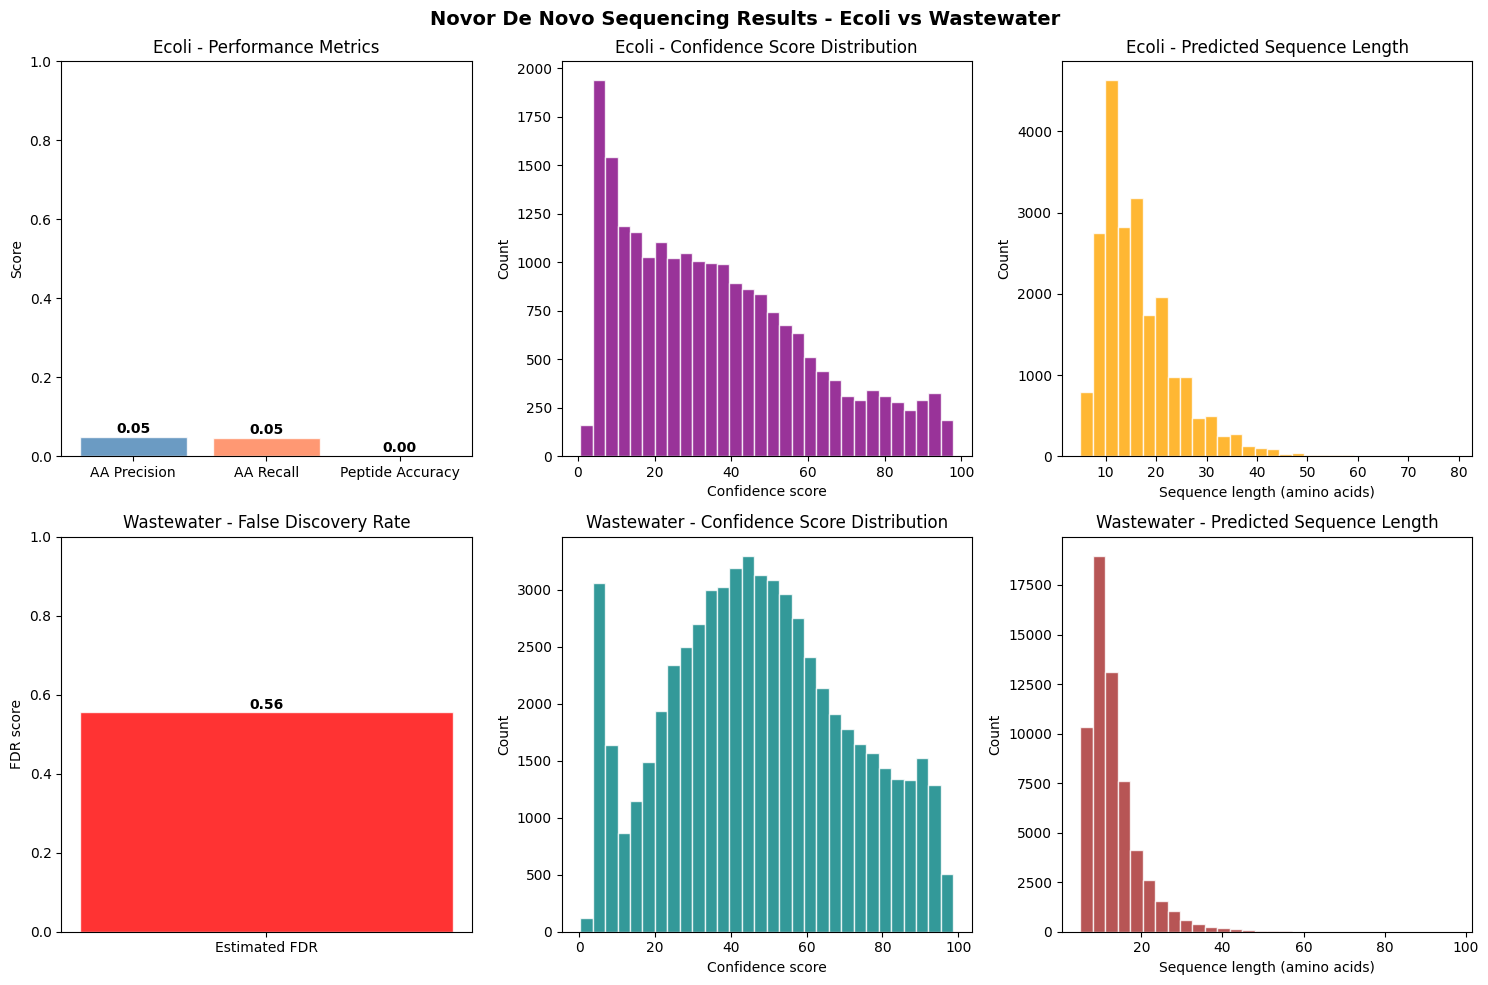

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Novor De Novo Sequencing Results - Ecoli vs Wastewater',
             fontsize=14, fontweight='bold')

# Plot 1 - Novor Ecoli Performance Metrics
metrics = ['AA Precision', 'AA Recall', 'Peptide Accuracy']
values = [novor_aa_precision, novor_aa_recall, novor_peptide_acc]
colors = ['steelblue', 'coral', 'green']

axes[0,0].bar(metrics, values, color=colors, alpha=0.8, edgecolor='white')
axes[0,0].set_title('Ecoli - Performance Metrics')
axes[0,0].set_ylabel('Score')
axes[0,0].set_ylim(0, 1)
for i, v in enumerate(values):
    axes[0,0].text(i, v + 0.01, f'{v:.2f}',
                   ha='center', fontweight='bold')

# Plot 2 - Novor Ecoli Confidence Score Distribution
axes[0,1].hist(novor_ecoli_combined['confidence_score'],
               bins=30, color='purple', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Ecoli - Confidence Score Distribution')
axes[0,1].set_xlabel('Confidence score')
axes[0,1].set_ylabel('Count')

# Plot 3 - Novor Ecoli Predicted Sequence Length
ecoli_seq_lengths_novor = novor_ecoli_combined['predicted_sequence'].apply(len)
axes[0,2].hist(ecoli_seq_lengths_novor, bins=30,
               color='orange', alpha=0.8, edgecolor='white')
axes[0,2].set_title('Ecoli - Predicted Sequence Length')
axes[0,2].set_xlabel('Sequence length (amino acids)')
axes[0,2].set_ylabel('Count')

# Plot 4 - Novor Wastewater FDR
axes[1,0].bar(['Estimated FDR'], [novor_ww_fdr],
               color='red', alpha=0.8, edgecolor='white')
axes[1,0].set_title('Wastewater - False Discovery Rate')
axes[1,0].set_ylabel('FDR score')
axes[1,0].set_ylim(0, 1)
axes[1,0].text(0, novor_ww_fdr + 0.01,
               f'{novor_ww_fdr:.2f}',
               ha='center', fontweight='bold')

# Plot 5 - Novor Wastewater Confidence Score Distribution
axes[1,1].hist(novor_ww_combined['confidence_score'],
               bins=30, color='teal', alpha=0.8, edgecolor='white')
axes[1,1].set_title('Wastewater - Confidence Score Distribution')
axes[1,1].set_xlabel('Confidence score')
axes[1,1].set_ylabel('Count')

# Plot 6 - Novor Wastewater Predicted Sequence Length
ww_seq_lengths_novor = novor_ww_combined['predicted_sequence'].apply(len)
axes[1,2].hist(ww_seq_lengths_novor, bins=30,
               color='brown', alpha=0.8, edgecolor='white')
axes[1,2].set_title('Wastewater - Predicted Sequence Length')
axes[1,2].set_xlabel('Sequence length (amino acids)')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.show()

I have visualized the Novor tool result for the Ecoli and the Wastewater dataset and have observed that the novor confidence score distributions are different for both of these.

The wastewater predicted sequence lengths are more uniform and short as compared to the ecoli which shows that wastewater contains more consistent sized peptides.

InstaNovo Sequencing tool

In [8]:
!pip install instanovo -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.8/164.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.8/487.8 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 136.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [9]:
!pip install torch==2.5.0 torchvision==0.20.0 --index-url https://download.pytorch.org/whl/cu121 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 79.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 113.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 63.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 143.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 21.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 46.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 21.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 13.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

In [9]:
import instanovo

In [12]:
mzml_ecoli_1 = ecoli_path + 'Ecoli_EV_1.mzML'
instanovo_output_1 = '/content/instanovo_output/instanovo_ecoli_ev1.csv'

os.makedirs('/content/instanovo_output', exist_ok=True)

start_time_1 = time.time()

!instanovo predict \
    --data-path {mzml_ecoli_1} \
    --output-path {instanovo_output_1} \
    --denovo \
    --no-refinement 2>&1

total_time_1 = (time.time() - start_time_1) / 60
print(f"\nEcoli EV sample 1 takes time : {total_time_1:.1f} minutes")

[05/07/26 03:34:20] INFO     Initializing InstaNovo inference.                                                                                                                 
[05/07/26 03:34:23] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-05-07 03:34:26.336368: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 03:34:26.399604: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-05-07 03:34

Here I have run InstaNovo tool on the first Ecoli dataset. A total of 10881 spectra are their which I have processed in and it took 11.8 minutes which I have observed is slow than Casanovo and Novor due to the use of beam search decoding with 5 beams.

In [14]:
mzml_ecoli_2 = ecoli_path + 'Ecoli_EV_2.mzML'
instanovo_output_2 = '/content/instanovo_output/instanovo_ecoli_ev2.csv'

start_time_2 = time.time()

!instanovo predict \
    --data-path {mzml_ecoli_2} \
    --output-path {instanovo_output_2} \
    --denovo \
    --no-refinement 2>&1

total_time_2 = (time.time() - start_time_2) / 60
print(f"\nEcoli EV sample 2 takes time : {total_time_2:.1f} minutes")

[05/07/26 03:58:15] INFO     Initializing InstaNovo inference.                                                                                                                 
[05/07/26 03:58:18] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-05-07 03:58:20.585903: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 03:58:20.650053: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-05-07 03:58

The processing time for Ecoli EV sample 2 took 10.7 minutes and is consistent like the previous Ecoli EV 1 which shows stable performance, the ecoli files together generate 21805 predictions.

In [15]:
wastewater_instanovo = {
    'wastewater_Sample1_1.mzML' : '/content/instanovo_output/instanovo_ww_s1_1.csv',
    'wastewater_Sample1_2.mzML' : '/content/instanovo_output/instanovo_ww_s1_2.csv',
    'wastewater_Sample2_1.mzML' : '/content/instanovo_output/instanovo_ww_s2_1.csv',
    'wastewater_Sample2_2.mzML' : '/content/instanovo_output/instanovo_ww_s2_2.csv',
}

overall_start = time.time()

for sample_file, output_file in wastewater_instanovo.items():
    mzml_input = wastewater_path + sample_file

    sample_start = time.time()

    !instanovo predict \
        --data-path {mzml_input} \
        --output-path {output_file} \
        --denovo \
        --no-refinement 2>&1

    sample_time = (time.time() - sample_start) / 60
    print(f"Wastewater sample completed in : {sample_time:.1f} minutes")

overall_time = (time.time() - overall_start) / 60
print(f"Wastewater sequencing is completed in total time of : {overall_time:.1f} minutes")

[05/07/26 04:20:09] INFO     Initializing InstaNovo inference.                                                                                                                 
[05/07/26 04:20:11] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-05-07 04:20:14.275508: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 04:20:14.340981: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-05-07 04:20

I have run InstaNovo on all the 4 wastewater files and it took time of 59.6 minutes to process all the files. This shows InstaNovo tool is slow as compared to Casanovo and Novor.

In [16]:
def parse_instanovo_output(filepath):

    print(f"Parsing results from : {os.path.basename(filepath)}")

    result_df = pd.read_csv(filepath)

    print(f"Total number of predictions detected : {len(result_df)}")
    print(f"Columns detected : {result_df.columns.tolist()}")

    return result_df

print("Parsing InstaNovo results for Ecoli EV Samples")
print("-" * 55)

instanovo_ev1 = parse_instanovo_output(
    '/content/instanovo_output/instanovo_ecoli_ev1.csv'
)
print()
instanovo_ev2 = parse_instanovo_output(
    '/content/instanovo_output/instanovo_ecoli_ev2.csv'
)

# Here I am combining both the Ecoli results
instanovo_ecoli_combined = pd.concat(
    [instanovo_ev1, instanovo_ev2],
    ignore_index=True
)
print(f"\nAll of the combined Ecoli predictions of InstaNovo : {len(instanovo_ecoli_combined)}")

Parsing InstaNovo results for Ecoli EV Samples
-------------------------------------------------------
Parsing results from : instanovo_ecoli_ev1.csv
Total number of predictions detected : 10881
Columns detected : ['experiment_name', 'scan_number', 'spectrum_id', 'precursor_mz', 'precursor_charge', 'prediction_id', 'predictions', 'log_probs', 'token_log_probs', 'group', 'predictions_beam_0', 'predictions_log_probability_beam_0', 'predictions_token_log_probabilities_beam_0', 'predictions_beam_1', 'predictions_log_probability_beam_1', 'predictions_token_log_probabilities_beam_1', 'predictions_beam_2', 'predictions_log_probability_beam_2', 'predictions_token_log_probabilities_beam_2', 'predictions_beam_3', 'predictions_log_probability_beam_3', 'predictions_token_log_probabilities_beam_3', 'predictions_beam_4', 'predictions_log_probability_beam_4', 'predictions_token_log_probabilities_beam_4', 'predictions_tokenised', 'delta_mass_ppm']

Parsing results from : instanovo_ecoli_ev2.csv
Total 

I have parsed the Ecoli files using pandas, the other tools casanovo and novor required custom parsing but instanovo saves the predictions and loads it directly. A well structured CSV format makes parsing quite simple compared to novor's custom output file format.

In [17]:
print("Parsing InstaNovo results for the wastewater samples")
print("-" * 55)

instanovo_ww_files = [
    '/content/instanovo_output/instanovo_ww_s1_1.csv',
    '/content/instanovo_output/instanovo_ww_s1_2.csv',
    '/content/instanovo_output/instanovo_ww_s2_1.csv',
    '/content/instanovo_output/instanovo_ww_s2_2.csv',
]

instanovo_ww_list = []

for output_file in instanovo_ww_files:
    ww_df = parse_instanovo_output(output_file)
    instanovo_ww_list.append(ww_df)
    print()

instanovo_ww_combined = pd.concat(
    instanovo_ww_list,
    ignore_index=True
)
print(f"All the combined wastewater predictions of InstaNovo : {len(instanovo_ww_combined)}")

Parsing InstaNovo results for the wastewater samples
-------------------------------------------------------
Parsing results from : instanovo_ww_s1_1.csv
Total number of predictions detected : 17100
Columns detected : ['experiment_name', 'scan_number', 'spectrum_id', 'precursor_mz', 'precursor_charge', 'prediction_id', 'predictions', 'log_probs', 'token_log_probs', 'group', 'predictions_beam_0', 'predictions_log_probability_beam_0', 'predictions_token_log_probabilities_beam_0', 'predictions_beam_1', 'predictions_log_probability_beam_1', 'predictions_token_log_probabilities_beam_1', 'predictions_beam_2', 'predictions_log_probability_beam_2', 'predictions_token_log_probabilities_beam_2', 'predictions_beam_3', 'predictions_log_probability_beam_3', 'predictions_token_log_probabilities_beam_3', 'predictions_beam_4', 'predictions_log_probability_beam_4', 'predictions_token_log_probabilities_beam_4', 'predictions_tokenised', 'delta_mass_ppm']

Parsing results from : instanovo_ww_s1_2.csv
Tota

I have parsed all the 4 InstaNovo wastewater files using pandas approach and I have combined the results into a single dataframe which I will use for the FDR evaluation. A total of 61150 predicted peptide sequences are present which have no ground truth present and I will evaluate this using the FDR analysis.

In [32]:
ground_truth_seq = ecoli_clean_df['Sequence'].tolist()

In [35]:
def aa_level_evaluation(pred, true):
    if not pred or not true:
        return 0.0, 0.0
    matches = sum(1 for p, t in zip(pred, true) if p == t)
    precision = matches / len(pred) if len(pred) > 0 else 0
    recall = matches / len(true) if len(true) > 0 else 0
    return precision, recall

def peptide_level_evaluation(pred, true):
    return 1 if pred == true else 0

In [37]:
instanovo_pred_seq = instanovo_ecoli_combined['predictions'].tolist()

instanovo_aa_precision_scores = []
instanovo_aa_recall_scores = []
instanovo_peptide_match_scores = []

total_evaluated = min(len(instanovo_pred_seq), len(ground_truth_seq))

print("Evaluation of the InstaNovo predictions on Ecoli dataset")
print("-" * 55)
print(f"Total number of predictions that is evaluated : {total_evaluated}")

for i in range(total_evaluated):
    pred = str(instanovo_pred_seq[i])
    true = str(ground_truth_seq[i])

    precision, recall = aa_level_evaluation(pred, true)
    instanovo_aa_precision_scores.append(precision)
    instanovo_aa_recall_scores.append(recall)
    instanovo_peptide_match_scores.append(peptide_level_evaluation(pred, true))

instanovo_aa_precision = sum(instanovo_aa_precision_scores) / len(instanovo_aa_precision_scores)
instanovo_aa_recall = sum(instanovo_aa_recall_scores) / len(instanovo_aa_recall_scores)
instanovo_peptide_acc = sum(instanovo_peptide_match_scores) / len(instanovo_peptide_match_scores)

print(f"\nInstaNovo evaluation results achieved on the Ecoli dataset:")
print(f"-" * 60)
print(f"Total numbers of predictions evaluated : {total_evaluated}")
print(f"Amino Acid precision : {instanovo_aa_precision:.4f} ({instanovo_aa_precision*100:.2f}%)")
print(f"Amino Acid recall : {instanovo_aa_recall:.4f} ({instanovo_aa_recall*100:.2f}%)")
print(f"Peptide level accuracy : {instanovo_peptide_acc:.4f} ({instanovo_peptide_acc*100:.2f}%)")

Evaluation of the InstaNovo predictions on Ecoli dataset
-------------------------------------------------------
Total number of predictions that is evaluated : 3162

InstaNovo evaluation results achieved on the Ecoli dataset:
------------------------------------------------------------
Total numbers of predictions evaluated : 3162
Amino Acid precision : 0.0471 (4.71%)
Amino Acid recall : 0.0496 (4.96%)
Peptide level accuracy : 0.0000 (0.00%)


I have observed that the InstaNovo amino acid precision of 4.71% shows that out of all the amino acids predicted only 4.71% matched the correct amino acid at the correct position. The amino acid recall of 4.96% is the highest achieved among all the others tools. The peptide level accuracy of 0% means no complete peptide sequence matches exactly which is quite normal for a tool without a database reference.

In [42]:
instanovo_ww_scores = instanovo_ww_combined['log_probs'].tolist()

instanovo_fdr_threshold = -1
low_confidence = sum(1 for s in instanovo_ww_scores if s < instanovo_fdr_threshold)
instanovo_ww_fdr = low_confidence / len(instanovo_ww_scores)

print("FDR Estimation for the InstaNovo wastewater dataset")
print("-" * 55)
print(f"Total number of wastewater predictions : {len(instanovo_ww_scores)}")
print(f"Average confidence score achieved : {sum(instanovo_ww_scores)/len(instanovo_ww_scores):.4f}")
print(f"Predictions scored below -1 : {low_confidence}")
print(f"Estimated FDR : {instanovo_ww_fdr:.4f} ({instanovo_ww_fdr*100:.2f}%)")

FDR Estimation for the InstaNovo wastewater dataset
-------------------------------------------------------
Total number of wastewater predictions : 61150
Average confidence score achieved : -6.5795
Predictions scored below -1 : 36521
Estimated FDR : 0.5972 (59.72%)


I have got the instanovo estimated FDR of 59.72% which means that 36521 out of 61150 wastewater predictions are likely to be false discoveries whereas 24629 are likely correct. I have choosed a threshold value of -1 as it shows medium confidence in its log probability scale in the same manner how 0.05 shows medium confidence for csanovo and 50 shows medium confidence for novor.

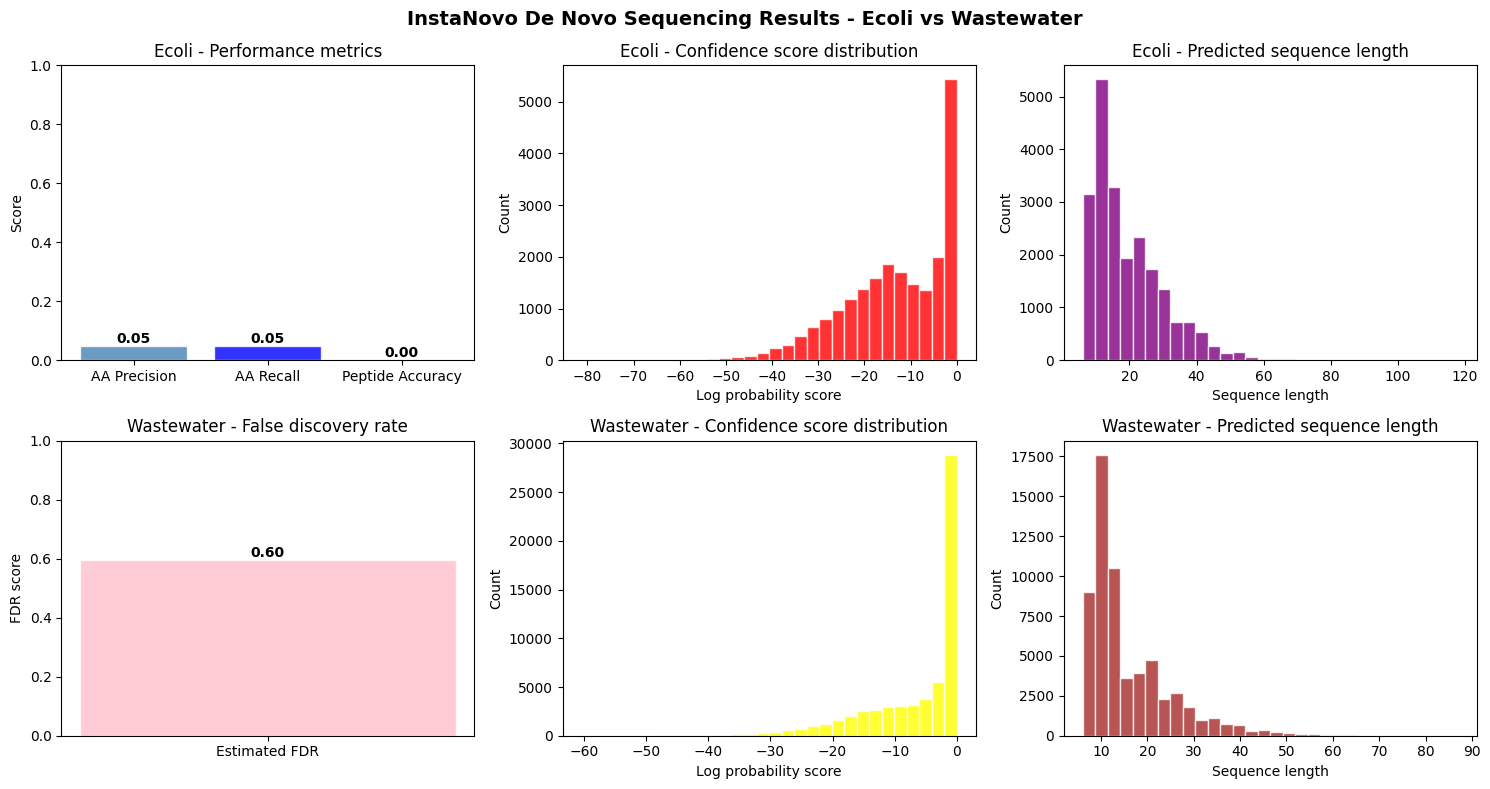

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('InstaNovo De Novo Sequencing Results - Ecoli vs Wastewater',
             fontsize=14, fontweight='bold')

# Plot 1 - InstaNovo Ecoli performance metrics
metrics = ['AA Precision', 'AA Recall', 'Peptide Accuracy']
values = [instanovo_aa_precision, instanovo_aa_recall, instanovo_peptide_acc]
colors = ['steelblue', 'blue', 'orange']

axes[0,0].bar(metrics, values, color=colors, alpha=0.8, edgecolor='white')
axes[0,0].set_title('Ecoli - Performance metrics')
axes[0,0].set_ylabel('Score')
axes[0,0].set_ylim(0, 1)
for i, v in enumerate(values):
    axes[0,0].text(i, v + 0.01, f'{v:.2f}',
                   ha='center', fontweight='bold')

# Plot 2 - InstaNovo Ecoli confidence score distribution
axes[0,1].hist(instanovo_ecoli_combined['log_probs'],
               bins=30, color='red', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Ecoli - Confidence score distribution')
axes[0,1].set_xlabel('Log probability score')
axes[0,1].set_ylabel('Count')

# Plot 3 - InstaNovo Ecoli Predicted sequence length
ecoli_seq_lengths_instanovo = instanovo_ecoli_combined['predictions'].apply(lambda x: len(str(x)))
axes[0,2].hist(ecoli_seq_lengths_instanovo, bins=30,
               color='purple', alpha=0.8, edgecolor='white')
axes[0,2].set_title('Ecoli - Predicted sequence length')
axes[0,2].set_xlabel('Sequence length')
axes[0,2].set_ylabel('Count')

# Plot 4 - InstaNovo Wastewater FDR
axes[1,0].bar(['Estimated FDR'], [instanovo_ww_fdr],
               color='pink', alpha=0.8, edgecolor='white')
axes[1,0].set_title('Wastewater - False discovery rate')
axes[1,0].set_ylabel('FDR score')
axes[1,0].set_ylim(0, 1)
axes[1,0].text(0, instanovo_ww_fdr + 0.01,
               f'{instanovo_ww_fdr:.2f}',
               ha='center', fontweight='bold')

# Plot 5 - InstaNovo Wastewater Confidence score distribution
axes[1,1].hist(instanovo_ww_combined['log_probs'],
               bins=30, color='yellow', alpha=0.8, edgecolor='white')
axes[1,1].set_title('Wastewater - Confidence score distribution')
axes[1,1].set_xlabel('Log probability score')
axes[1,1].set_ylabel('Count')

# Plot 6 - InstaNovo Wastewater Predicted sequence length
ww_seq_lengths_instanovo = instanovo_ww_combined['predictions'].apply(lambda x: len(str(x)))
axes[1,2].hist(ww_seq_lengths_instanovo, bins=30,
               color='brown', alpha=0.8, edgecolor='white')
axes[1,2].set_title('Wastewater - Predicted sequence length')
axes[1,2].set_xlabel('Sequence length')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.show()

I have visualized the instanovo results for both the Ecoli and the Wastewater datasets and plotted all the performance. The confidence score of wastewater has 28000 predictions which are concentrated near 0 whereas ecoli has a more spread out distribution.

The high confidence on wastewater is consistent with casanovo and novor tools which specifies that the wastewater spectra is more easy to predict than ecoli.

The FDR of 0.60 on wastewater shows that Instanovo provides balanced confidence on environmental samples.

The Instanovo shows high recall and has more confident predictions on the wastewater making it reliable for discovery applications.

InstaNovo+ Sequencing tool

In [6]:
mzml_ecoli_1 = ecoli_path + 'Ecoli_EV_1.mzML'
instanovo_plus_output_1 = '/content/instanovoplus_output/instanovoplus_ecoli_ev1.csv'

os.makedirs('/content/instanovoplus_output', exist_ok=True)

start_time_1 = time.time()

!instanovo predict \
    --data-path {mzml_ecoli_1} \
    --output-path {instanovo_plus_output_1} \
    --denovo \
    --with-refinement 2>&1

total_time_1 = (time.time() - start_time_1) / 60
print(f"\nEcoli EV sample 1 takes time : {total_time_1:.1f} minutes")

[05/08/26 03:58:54] INFO     Initializing InstaNovo inference.                                                                                                                 
[05/08/26 03:58:57] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-05-08 03:59:00.720197: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 03:59:00.783981: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-05-08 03:59

Here I have run Instanovo+ on the first Ecoli mzML file using the
same instanovo command what I have used in the previous tool and it takes 20.6 minutes to run which is long than the Instanovo tool because of the extra diffusion refinement step.

In [7]:
mzml_ecoli_2 = ecoli_path + 'Ecoli_EV_2.mzML'
instanovo_plus_output_2 = '/content/instanovoplus_output/instanovoplus_ecoli_ev2.csv'

start_time_2 = time.time()

!instanovo predict \
    --data-path {mzml_ecoli_2} \
    --output-path {instanovo_plus_output_2} \
    --denovo \
    --with-refinement 2>&1

total_time_2 = (time.time() - start_time_2) / 60
print(f"\nEcoli EV sample 2 takes time : {total_time_2:.1f} minutes")

[05/08/26 04:21:41] INFO     Initializing InstaNovo inference.                                                                                                                 
[05/08/26 04:21:44] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-05-08 04:21:46.538869: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 04:21:46.603854: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-05-08 04:21

Now I have run the Instanovo+ on the second Ecoli mzML file using the same configuration. The processing time of 19.6 minutes is consistent with EV1 which shows stable performance with refinement.

In [7]:
wastewater_instanovoplus = {
    'wastewater_Sample1_1.mzML' : '/content/instanovoplus_output/instanovoplus_ww_s1_1.csv',
    'wastewater_Sample1_2.mzML' : '/content/instanovoplus_output/instanovoplus_ww_s1_2.csv',
    'wastewater_Sample2_1.mzML' : '/content/instanovoplus_output/instanovoplus_ww_s2_1.csv',
    'wastewater_Sample2_2.mzML' : '/content/instanovoplus_output/instanovoplus_ww_s2_2.csv',
}

overall_start = time.time()

for sample_file, output_file in wastewater_instanovoplus.items():
    mzml_input = wastewater_path + sample_file

    sample_start = time.time()

    !instanovo predict \
        --data-path {mzml_input} \
        --output-path {output_file} \
        --denovo \
        --with-refinement 2>&1

    sample_time = (time.time() - sample_start) / 60
    print(f"Wastewater sample completed in : {sample_time:.1f} minutes")

overall_time = (time.time() - overall_start) / 60
print(f"Wastewater sequencing completed in total time of : {overall_time:.1f} minutes")

[05/08/26 14:25:42] INFO     Initializing InstaNovo inference.                                                                                                                 
[05/08/26 14:25:45] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-05-08 14:25:49.111386: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 14:25:49.176668: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-05-08 14:25

Now I am running the Instanovo+ tool on all the 4 wastewater files using a loop
that processes each file sequentially with diffusion based refinement. The total running time of 110 minutes makes InstaNovo+ the most slowest tool as of now.

In [13]:
def parse_instanovo_output(filepath):

    print(f"Parsing the results from : {os.path.basename(filepath)}")

    result_df = pd.read_csv(filepath)

    print(f"Total number of predictions detected : {len(result_df)}")
    print(f"Columns detected : {result_df.columns.tolist()}")

    return result_df

ecoli_excel_1 = ecoli_path + 'Database search output_Ecoli_EV_1.xlsx'
ecoli_excel_2 = ecoli_path + 'Database search output_Ecoli_EV_2.xlsx'

ecoli_df_1 = pd.read_excel(ecoli_excel_1)
ecoli_df_2 = pd.read_excel(ecoli_excel_2)
ecoli_clean_df = pd.concat([ecoli_df_1, ecoli_df_2], ignore_index=True)
ground_truth_seq = ecoli_clean_df['Sequence'].tolist()

def aa_level_evaluation(pred, true):
    if not pred or not true:
        return 0.0, 0.0
    matches = sum(1 for p, t in zip(pred, true) if p == t)
    precision = matches / len(pred) if len(pred) > 0 else 0
    recall = matches / len(true) if len(true) > 0 else 0
    return precision, recall

def peptide_level_evaluation(pred, true):
    return 1 if pred == true else 0

print(f"Ground truth is loaded: {len(ground_truth_seq)} peptides")

Ground truth is loaded: 3162 peptides


In [15]:
print("Parsing InstaNovo+ results for Ecoli EV samples")
print("-" * 50)

instanovoplus_ev1 = parse_instanovo_output(
    '/content/instanovoplus_output/instanovoplus_ecoli_ev1.csv'
)
print()
instanovoplus_ev2 = parse_instanovo_output(
    '/content/instanovoplus_output/instanovoplus_ecoli_ev2.csv'
)

# Here I am combining the Ecoli results
instanovoplus_ecoli_combined = pd.concat(
    [instanovoplus_ev1, instanovoplus_ev2],
    ignore_index=True
)

print(f"\nAll the combined ecoli predictions of InstaNovo+ : {len(instanovoplus_ecoli_combined)}")

Parsing InstaNovo+ results for Ecoli EV samples
--------------------------------------------------
Parsing the results from : instanovoplus_ecoli_ev1.csv
Total number of predictions detected : 10881
Columns detected : ['experiment_name', 'scan_number', 'spectrum_id', 'precursor_mz', 'precursor_charge', 'prediction_id', 'predictions', 'log_probs', 'token_log_probs', 'group', 'instanovo_predictions', 'instanovo_prediction_log_probability', 'instanovo_prediction_token_log_probabilities', 'instanovo_predictions_beam_0', 'instanovo_predictions_log_probability_beam_0', 'instanovo_predictions_token_log_probabilities_beam_0', 'instanovo_predictions_beam_1', 'instanovo_predictions_log_probability_beam_1', 'instanovo_predictions_token_log_probabilities_beam_1', 'instanovo_predictions_beam_2', 'instanovo_predictions_log_probability_beam_2', 'instanovo_predictions_token_log_probabilities_beam_2', 'instanovo_predictions_beam_3', 'instanovo_predictions_log_probability_beam_3', 'instanovo_predictions

Here I have done the parsing successfully for the Ecoli files which generates 21805 total number of predictions. The predictions column comprises of the final refined output which combines both the models in order to get the best accuracy.

In [18]:
print("Parsing Instanovo+ results for Wastewater samples")
print("-" * 45)

instanovoplus_ww_files = [
    '/content/instanovoplus_output/instanovoplus_ww_s1_1.csv',
    '/content/instanovoplus_output/instanovoplus_ww_s1_2.csv',
    '/content/instanovoplus_output/instanovoplus_ww_s2_1.csv',
    '/content/instanovoplus_output/instanovoplus_ww_s2_2.csv',
]

instanovoplus_ww_list = []

for output_file in instanovoplus_ww_files:
    ww_df = parse_instanovo_output(output_file)
    instanovoplus_ww_list.append(ww_df)
    print()

# Here I am combining all the wastewater results
instanovoplus_ww_combined = pd.concat(
    instanovoplus_ww_list,
    ignore_index=True
)
print(f"All the combined watewater predictions of InstaNovo+ : {len(instanovoplus_ww_combined)}")

Parsing Instanovo+ results for Wastewater samples
---------------------------------------------
Parsing the results from : instanovoplus_ww_s1_1.csv
Total number of predictions detected : 17100
Columns detected : ['experiment_name', 'scan_number', 'spectrum_id', 'precursor_mz', 'precursor_charge', 'prediction_id', 'predictions', 'log_probs', 'token_log_probs', 'group', 'instanovo_predictions', 'instanovo_prediction_log_probability', 'instanovo_prediction_token_log_probabilities', 'instanovo_predictions_beam_0', 'instanovo_predictions_log_probability_beam_0', 'instanovo_predictions_token_log_probabilities_beam_0', 'instanovo_predictions_beam_1', 'instanovo_predictions_log_probability_beam_1', 'instanovo_predictions_token_log_probabilities_beam_1', 'instanovo_predictions_beam_2', 'instanovo_predictions_log_probability_beam_2', 'instanovo_predictions_token_log_probabilities_beam_2', 'instanovo_predictions_beam_3', 'instanovo_predictions_log_probability_beam_3', 'instanovo_predictions_toke

Now the wastewater files are parsed successfully and it generates 61150 peptide sequences. These predictions have no ground truth available so further I will evaluate this using FDR analysis.

In [19]:
instanovoplus_pred_seq = instanovoplus_ecoli_combined['predictions'].tolist()

instanovoplus_aa_precision_scores = []
instanovoplus_aa_recall_scores = []
instanovoplus_peptide_match_scores = []

total_evaluated = min(len(instanovoplus_pred_seq), len(ground_truth_seq))

print("Evaluation of the InstaNovo predictions on Ecoli dataset")
print("-" * 55)
print(f"Total number of predictions that is evaluated: {total_evaluated}")

for i in range(total_evaluated):
    pred = str(instanovoplus_pred_seq[i])
    true = str(ground_truth_seq[i])

    precision, recall = aa_level_evaluation(pred, true)
    instanovoplus_aa_precision_scores.append(precision)
    instanovoplus_aa_recall_scores.append(recall)
    instanovoplus_peptide_match_scores.append(peptide_level_evaluation(pred, true))

instanovoplus_aa_precision = sum(instanovoplus_aa_precision_scores) / len(instanovoplus_aa_precision_scores)
instanovoplus_aa_recall = sum(instanovoplus_aa_recall_scores) / len(instanovoplus_aa_recall_scores)
instanovoplus_peptide_acc = sum(instanovoplus_peptide_match_scores) / len(instanovoplus_peptide_match_scores)

print(f"\nInstanovo+ evaluation results achieved on the Ecoli dataset:")
print(f"-" * 60)
print(f"Total numbers of predictions evaluated: {total_evaluated}")
print(f"Amino Acid precision : {instanovoplus_aa_precision:.4f} ({instanovoplus_aa_precision*100:.2f}%)")
print(f"Amino Acid recall : {instanovoplus_aa_recall:.4f} ({instanovoplus_aa_recall*100:.2f}%)")
print(f"Peptide level accuracy : {instanovoplus_peptide_acc:.4f} ({instanovoplus_peptide_acc*100:.2f}%)")

Evaluation of the InstaNovo predictions on Ecoli dataset
-------------------------------------------------------
Total number of predictions that is evaluated: 3162

Instanovo+ evaluation results achieved on the Ecoli dataset:
------------------------------------------------------------
Total numbers of predictions evaluated: 3162
Amino Acid precision : 0.0507 (5.07%)
Amino Acid recall : 0.0524 (5.24%)
Peptide level accuracy : 0.0000 (0.00%)


Here I am evaluating the predictions against the ground truth sequences from the database search. The Instanovo+ amino acid precision of 5.07% is improved compared to the Instanovo's tool of 4.71% which confirms that the diffusion refinement model adds accuracy. The Instanovo+ amino acid recall of 5.24% is also improved compared to the Instanovo's 4.96% recovering more true amino acids. The accuracy of 0.00% across all the tools is a characteristic of de novo sequencing without database reference.

In [20]:
instanovoplus_ww_scores = instanovoplus_ww_combined['log_probs'].tolist()

instanovoplus_fdr_threshold = -1
low_confidence = sum(1 for s in instanovoplus_ww_scores if s < instanovoplus_fdr_threshold)
instanovoplus_ww_fdr = low_confidence / len(instanovoplus_ww_scores)

print("FDR Estimation for the InstaNovo+ wastewater dataset")
print("-" * 55)
print(f"Total number of wastewater predictions : {len(instanovoplus_ww_scores)}")
print(f"Average confidence score achieved : {sum(instanovoplus_ww_scores)/len(instanovoplus_ww_scores):.4f}")
print(f"Predictions scored below -1 : {low_confidence}")
print(f"Estimated FDR : {instanovoplus_ww_fdr:.4f} ({instanovoplus_ww_fdr*100:.2f}%)")

FDR Estimation for the InstaNovo+ wastewater dataset
-------------------------------------------------------
Total number of wastewater predictions : 61150
Average confidence score achieved : -0.5167
Predictions scored below -1 : 11402
Estimated FDR : 0.1865 (18.65%)


Here I am calculating the False Discovery Rate for Instanovo+ tool wastewater
predictions using the same threshold of -1 which I have used earlier for Instanovo since both the tools use the same log probability scoring scale. Instanovo+ FDR of 18.65% over Instanovo 59.72% represents a 41% reduction in the false discoveries and this is the best FDR among all the 4 tools.

The average confidence score has also improved from -6.58 to -0.52 wwhich specifies that the predictions are now much closer to certainty and this demonstrates that the diffusion based refinement is a breakthrough approach for de novo peptide sequencing.

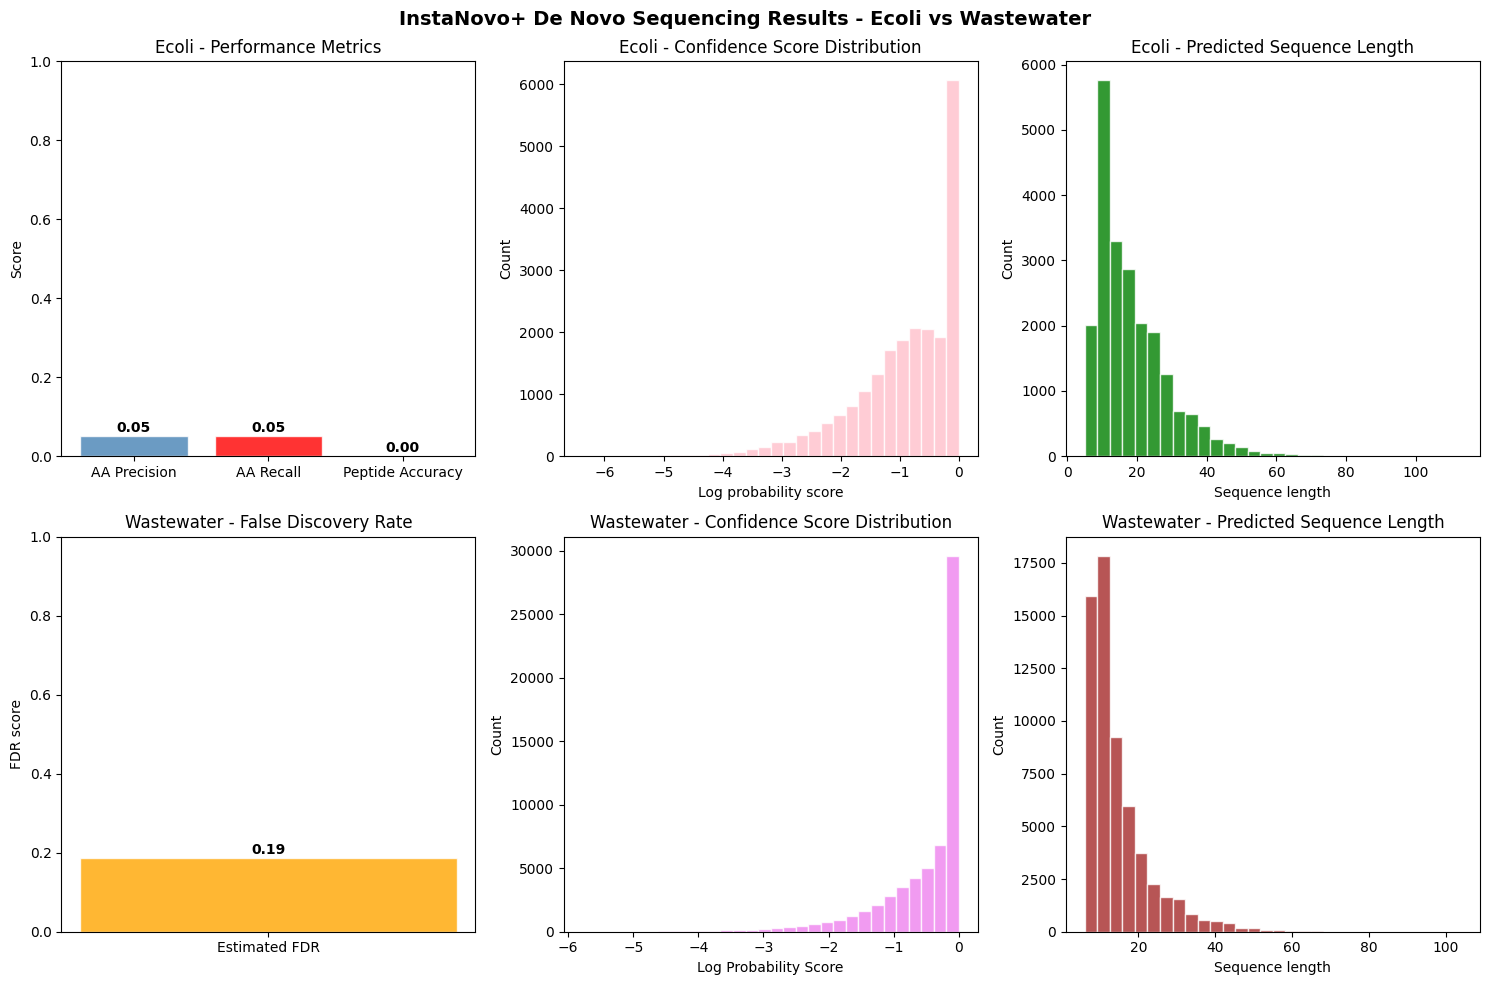

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('InstaNovo+ De Novo Sequencing Results - Ecoli vs Wastewater',
             fontsize=14, fontweight='bold')

# Plot 1 - InstaNovo+ Ecoli Performance Metrics
metrics = ['AA Precision', 'AA Recall', 'Peptide Accuracy']
values = [instanovoplus_aa_precision, instanovoplus_aa_recall, instanovoplus_peptide_acc]
colors = ['steelblue', 'red', 'yellow']

axes[0,0].bar(metrics, values, color=colors, alpha=0.8, edgecolor='white')
axes[0,0].set_title('Ecoli - Performance Metrics')
axes[0,0].set_ylabel('Score')
axes[0,0].set_ylim(0, 1)
for i, v in enumerate(values):
    axes[0,0].text(i, v + 0.01, f'{v:.2f}',
                   ha='center', fontweight='bold')

# Plot 2 - InstaNovo+ Ecoli Confidence Score Distribution
axes[0,1].hist(instanovoplus_ecoli_combined['log_probs'],
               bins=30, color='pink', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Ecoli - Confidence Score Distribution')
axes[0,1].set_xlabel('Log probability score')
axes[0,1].set_ylabel('Count')

# Plot 3 - InstaNovo+ Ecoli Predicted Sequence Length
ecoli_seq_lengths = instanovoplus_ecoli_combined['predictions'].apply(lambda x: len(str(x)))
axes[0,2].hist(ecoli_seq_lengths, bins=30,
               color='green', alpha=0.8, edgecolor='white')
axes[0,2].set_title('Ecoli - Predicted Sequence Length')
axes[0,2].set_xlabel('Sequence length')
axes[0,2].set_ylabel('Count')

# Plot 4 - InstaNovo+ Wastewater FDR
axes[1,0].bar(['Estimated FDR'], [instanovoplus_ww_fdr],
               color='orange', alpha=0.8, edgecolor='white')
axes[1,0].set_title('Wastewater - False Discovery Rate')
axes[1,0].set_ylabel('FDR score')
axes[1,0].set_ylim(0, 1)
axes[1,0].text(0, instanovoplus_ww_fdr + 0.01,
               f'{instanovoplus_ww_fdr:.2f}',
               ha='center', fontweight='bold')

# Plot 5 - InstaNovo+ Wastewater Confidence Score Distribution
axes[1,1].hist(instanovoplus_ww_combined['log_probs'],
               bins=30, color='violet', alpha=0.8, edgecolor='white')
axes[1,1].set_title('Wastewater - Confidence Score Distribution')
axes[1,1].set_xlabel('Log Probability Score')
axes[1,1].set_ylabel('Count')

# Plot 6 - InstaNovo+ Wastewater Predicted Sequence Length
ww_seq_lengths = instanovoplus_ww_combined['predictions'].apply(lambda x: len(str(x)))
axes[1,2].hist(ww_seq_lengths, bins=30,
               color='brown', alpha=0.8, edgecolor='white')
axes[1,2].set_title('Wastewater - Predicted Sequence Length')
axes[1,2].set_xlabel('Sequence length')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.show()

Here I have visualized the Instanovo+ de novo sequencing results for
both the Ecoli and the Wastewater datasets. The wastewater FDR of 0.19 is low than all the other tools and the wastewater confidence distribution shows nearly 30000 predictions clustered at maximum confidence.

The predicted sequence length remain consistent at 10 to 12 amino acids matching all the other tools and confirms tryptic digestion patterns.

The improved FDR makes InstaNovo+ tool best for the downstream applications like Unipept organism mapping.

 Comparison between the 4 tools

In [33]:
# Casanovo metrics
casanovo_aa_precision = 0.0544
casanovo_aa_recall = 0.0533
casanovo_peptide_acc = 0.0000
casanovo_ww_fdr = 0.66

# Novor metrics
novor_aa_precision = 0.0478
novor_aa_recall = 0.0471
novor_peptide_acc = 0.0000
novor_ww_fdr = 0.5552

# InstaNovo metrics
instanovo_aa_precision = 0.0471
instanovo_aa_recall = 0.0496
instanovo_peptide_acc = 0.0000
instanovo_ww_fdr = 0.5972

# InstaNovo+ metrics
instanovoplus_aa_precision = 0.0507
instanovoplus_aa_recall = 0.0524
instanovoplus_peptide_acc = 0.0000
instanovoplus_ww_fdr = 0.1865

print(f"Casanovo : Precision={casanovo_aa_precision*100:.2f}%, Recall={casanovo_aa_recall*100:.2f}%, FDR={casanovo_ww_fdr*100:.2f}%")
print(f"Novor : Precision={novor_aa_precision*100:.2f}%, Recall={novor_aa_recall*100:.2f}%, FDR={novor_ww_fdr*100:.2f}%")
print(f"InstaNovo : Precision={instanovo_aa_precision*100:.2f}%, Recall={instanovo_aa_recall*100:.2f}%, FDR={instanovo_ww_fdr*100:.2f}%")
print(f"InstaNovo+ : Precision={instanovoplus_aa_precision*100:.2f}%, Recall={instanovoplus_aa_recall*100:.2f}%, FDR={instanovoplus_ww_fdr*100:.2f}%")

Casanovo : Precision=5.44%, Recall=5.33%, FDR=66.00%
Novor : Precision=4.78%, Recall=4.71%, FDR=55.52%
InstaNovo : Precision=4.71%, Recall=4.96%, FDR=59.72%
InstaNovo+ : Precision=5.07%, Recall=5.24%, FDR=18.65%


I have just used the hardcoded values that I have achieved from the above evaluations in order to run the previous cells again will take alot of time to come to the final comparison table thats why.

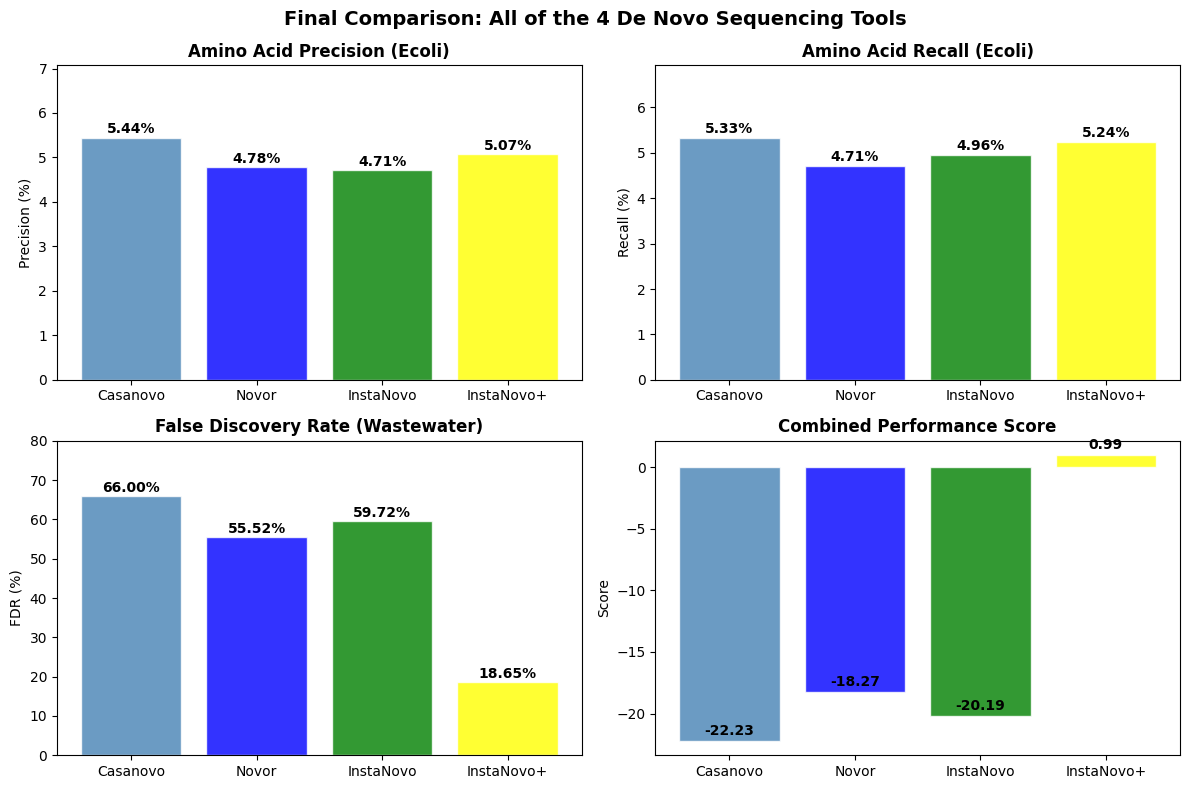


Final summary table of the results
Tool            Precision    Recall       FDR         
------------------------------------------------------------
Casanovo        5.44       % 5.33       % 66.00      %
Novor           4.78       % 4.71       % 55.52      %
InstaNovo       4.71       % 4.96       % 59.72      %
InstaNovo+      5.07       % 5.24       % 18.65      %

Important observations
Best precision achieved : Casanovo (5.44%)
Best recall achieved : Casanovo (5.33%)
Best FDR achieved : InstaNovo+ (18.65%)
Best overall performance : InstaNovo+


In [34]:
tools = ['Casanovo', 'Novor', 'InstaNovo', 'InstaNovo+']
precision_values = [
    casanovo_aa_precision * 100,
    novor_aa_precision * 100,
    instanovo_aa_precision * 100,
    instanovoplus_aa_precision * 100
]
recall_values = [
    casanovo_aa_recall * 100,
    novor_aa_recall * 100,
    instanovo_aa_recall * 100,
    instanovoplus_aa_recall * 100
]
fdr_values = [
    casanovo_ww_fdr * 100,
    novor_ww_fdr * 100,
    instanovo_ww_fdr * 100,
    instanovoplus_ww_fdr * 100
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Final Comparison: All of the 4 De Novo Sequencing Tools',
             fontsize=14, fontweight='bold')

colors = ['steelblue', 'blue', 'green', 'yellow']

# Plot 1 - AA Precision Comparison
axes[0,0].bar(tools, precision_values, color=colors, alpha=0.8, edgecolor='white')
axes[0,0].set_title('Amino Acid Precision (Ecoli)', fontweight='bold')
axes[0,0].set_ylabel('Precision (%)')
axes[0,0].set_ylim(0, max(precision_values) * 1.3)
for i, v in enumerate(precision_values):
    axes[0,0].text(i, v + 0.1, f'{v:.2f}%',
                   ha='center', fontweight='bold')

# Plot 2 - AA Recall Comparison
axes[0,1].bar(tools, recall_values, color=colors, alpha=0.8, edgecolor='white')
axes[0,1].set_title('Amino Acid Recall (Ecoli)', fontweight='bold')
axes[0,1].set_ylabel('Recall (%)')
axes[0,1].set_ylim(0, max(recall_values) * 1.3)
for i, v in enumerate(recall_values):
    axes[0,1].text(i, v + 0.1, f'{v:.2f}%',
                   ha='center', fontweight='bold')

# Plot 3 - FDR Comparison
axes[1,0].bar(tools, fdr_values, color=colors, alpha=0.8, edgecolor='white')
axes[1,0].set_title('False Discovery Rate (Wastewater)', fontweight='bold')
axes[1,0].set_ylabel('FDR (%)')
axes[1,0].set_ylim(0, 80)
for i, v in enumerate(fdr_values):
    axes[1,0].text(i, v + 1, f'{v:.2f}%',
                   ha='center', fontweight='bold')

# Plot 4 - Combined Performance Score
combined_score = [(p + r - f/2) for p, r, f in zip(precision_values, recall_values, fdr_values)]
axes[1,1].bar(tools, combined_score, color=colors, alpha=0.8, edgecolor='white')
axes[1,1].set_title('Combined Performance Score', fontweight='bold')
axes[1,1].set_ylabel('Score')
for i, v in enumerate(combined_score):
    axes[1,1].text(i, v + 0.5, f'{v:.2f}',
                   ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Final summary table of the results")
print("=" * 50)
print(f"{'Tool':<15} {'Precision':<12} {'Recall':<12} {'FDR':<12}")
print("-" * 60)
for i in range(4):
    print(f"{tools[i]:<15} {precision_values[i]:<11.2f}% {recall_values[i]:<11.2f}% {fdr_values[i]:<11.2f}%")

print("\n" + "=" * 50)
print("Important observations")
print("=" * 50)
print(f"Best precision achieved : {tools[precision_values.index(max(precision_values))]} ({max(precision_values):.2f}%)")
print(f"Best recall achieved : {tools[recall_values.index(max(recall_values))]} ({max(recall_values):.2f}%)")
print(f"Best FDR achieved : {tools[fdr_values.index(min(fdr_values))]} ({min(fdr_values):.2f}%)")
print(f"Best overall performance : {tools[combined_score.index(max(combined_score))]}")

In this visualization, I am comparing all the 4 de novo sequencing tools and I can say that all the 4 tools cluster around 5% precision and recall thus they can be easily comparable on the Ecoli dataset.

The Instanovo+ is the best tool as their is 41% reduction in the FDR compared to Instanovo, 47% compared to Casanovo, and 37% compared to novor.

Novor is the fastest tool for running in terms of speed and Instanovo+ is the slowest in speed.

The four tools show high confidence on wastewater as compared to the ecoli dataset because the ground truth ecoli is more challenging.

References used:

Dr. Yinyin Ye, and the Ye Lab for the dataset and guidance.

Eloff, Kevin, et al. "InstaNovo enables diffusion-powered de novo peptide sequencing in large-scale proteomics experiments." Nature Machine Intelligence 7.4 (2025): 565-579.

Beslic, D., Tscheuschner, G., Renard, B. Y., Weller, M. G. & Muth, T. "Comprehensive evaluation of peptide de novo sequencing tools for monoclonal antibody assembly." Briefings in Bioinformatics 24, 542 (2023).

Ngoc Hieu, et al. "NovoBoard: a comprehensive framework for evaluating the false discovery rate and accuracy of de novo peptide sequencing." Molecular & Cellular Proteomics 23.11 (2024).